## 1. 📦 Import & Config

In [ ]:
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import wasserstein_distance

from utils import setup_logging, setup_random_seed, load_processed_store, simulate_mc_gbm,  plot_compare_dist, plot_compare_correlation, plot_compare_rolling_vol, _kl_divergence
from utils.paths import EXPERIMENTS_DIR, PROCESSED_DIR
from config import Config
from models import Diffusion, DiffusionTransformer

logger = setup_logging()

2026-04-29 15:18:10,850 - utils.setup - INFO - Logger is set up.


In [6]:
config = Config(
    device = "cuda:0",
    skip_optuna = False,
    # processed_name="trial02_w20h20a14seqd20inds20normw20tbs20rand78"
)
setup_random_seed(config.random_seed)

device = torch.device(config.device)
print(f"Device: {device}")

config.feature.symbols = [
   # Tech (12)
    "AAPL", "MSFT", "NVDA", "META", "GOOGL", "AMZN",
    "AMD", "TSLA", "ORCL", "CRM", "ADBE", "INTC",
    # Financials (8)
    "JPM", "BAC", "GS", "WFC", "MS", "BLK", "AXP", "C",
    # Healthcare (8)
    "JNJ", "UNH", "PFE", "ABBV", "MRK", "TMO", "ABT", "BMY",
    # Consumer (8)
    "KO", "WMT", "MCD", "NKE", "PG", "COST", "TGT", "SBUX",
    # Industrial/Energy (8)
    "CAT", "XOM", "CVX", "NEE", "BA", "HON", "UPS", "LMT",
    # Macro/ETF (6)
    "SPY", "TLT", "GLD", "EEM", "QQQ", "IWM"
]

test_day_trade = 1002 # 501 days
config.inference.window_size = 20
config.feature.sequence_depth = 20
config.train.epochs = 1000
config.inference.horizon = test_day_trade
config.inference.normalize_window = True
# Set horizon to the maximum possible given the window size and data length (322)

data_shifted = config.inference.horizon
config.inference.normalize_shift = data_shifted  # Not necessary to be the same as window_size, but it makes sense to use the same value
# ---------------------------------------
config.feature.indicator_shift = data_shifted  # Shift the indicators by the window size to avoid look-ahead bias
config.inference.test_batch_stride = config.inference.window_size

config.processed_name = f"trial06a{len(config.feature.symbols)}_w{config.inference.window_size}seqd{config.feature.sequence_depth}h{config.inference.horizon}rand{config.random_seed}"

config.train.use_scheduler = True
config.train.scheduler_type = "warmup_cosine"
# config.train.scheduler_type = "plateau"

config.name = f"{config.processed_name}_model-BATmC_scheduler-{config.train.scheduler_type}"
config.inference.n_paths = 1000

EXP_NAME    = "20260428_165751_trial06a50_w20seqd20h1002rand78_model-BATmC_scheduler-warmup_cosine_optuna"
CKPT_FILE   = "epoch1000_trial06a50_w20seqd20h1002rand78_model-BATmC_scheduler-warmup_cosine.pt"
SIM_NAME = f"trial06a{len(config.feature.symbols)}_w{config.inference.window_size}seqd{config.feature.sequence_depth}h{config.inference.horizon}_n{config.inference.n_paths}rand{config.random_seed}"

exp_dir     = Path(EXPERIMENTS_DIR) / EXP_NAME
ckpt_path   = exp_dir / "checkpoints" / CKPT_FILE
sim_dir  = Path(EXPERIMENTS_DIR) / "simulations" / SIM_NAME
sim_dir.mkdir(parents=True, exist_ok=True)



if not config.skip_optuna:
    with open(exp_dir / "optuna" / "best_params.json") as f:
        best_params = json.load(f)

    print("Best params:", json.dumps(best_params, indent=2))

    num_layers          = best_params["n_layers"]
    num_attention_heads = best_params["n_heads"]
    d_model             = best_params["d_model"]
    dim_feedforward     = best_params["d_model"] * best_params["ff_mult"]
    dropout             = best_params["dropout"]
    timesteps           = best_params["timesteps"]
    beta_start          = best_params["beta_start"]
    beta_end            = best_params["beta_end"]
else:
    # Use default values from config if not loading from Optuna
    num_layers          = config.model.n_layers
    num_attention_heads = config.model.n_heads
    d_model             = config.model.d_model
    dim_feedforward     = config.model.dim_feedforward
    dropout             = config.model.dropout
    timesteps           = config.model.noise_steps
    beta_start          = config.model.beta_start
    beta_end            = config.model.beta_end

print(f"Experiment : {exp_dir}")
print(f"Checkpoint : {ckpt_path}")
print(f"Sim output : {sim_dir}")

Device: cuda:0
Best params: {
  "d_model": 512,
  "ff_mult": 4,
  "n_heads": 8,
  "n_layers": 2,
  "dropout": 0.15000000000000002,
  "timesteps": 1750,
  "lr": 0.0007353480594814744,
  "weight_decay": 2.3937561078534302e-05,
  "beta_start": 0.0006269753941461424,
  "beta_end": 0.046788933463791066,
  "scheduler_type": "cosine"
}
Experiment : /home/narodom.y@FUSION.LAB/research/experiments/20260428_165751_trial06a50_w20seqd20h1002rand78_model-BATmC_scheduler-warmup_cosine_optuna
Checkpoint : /home/narodom.y@FUSION.LAB/research/experiments/20260428_165751_trial06a50_w20seqd20h1002rand78_model-BATmC_scheduler-warmup_cosine_optuna/checkpoints/epoch1000_trial06a50_w20seqd20h1002rand78_model-BATmC_scheduler-warmup_cosine.pt
Sim output : /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial06a50_w20seqd20h1002_n1000rand78


## 2 · Load Feature Store

In [7]:
parts, datasets, loaders, meta = load_processed_store(
    store_name   = config.processed_name,
    saved_dir    = Path(PROCESSED_DIR),
    batch_size   = config.train.batch_size,
    batch_size_test = config.train.batch_size_test,
    shuffle_train= False,
)


test_loader = loaders["test"]

# Shape info from first batch
sample = next(iter(test_loader))
B, A, T, C      = sample["x"].shape
C_cond          = sample["cond"].shape[-1]

print(f"x    shape : {sample['x'].shape}   → [B, A, T, C]")
print(f"cond shape : {sample['cond'].shape} → [B, A, T, C_cond]")
print(f"Assets     : {A}  |  Window : {T}  |  Channels : {C}  |  Cond channels : {C_cond}")

✅ Loaded feature store  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial06a50_w20seqd20h1002rand78
   train: 1051 windows
   val  : 101 windows
   test : 49 windows
x    shape : torch.Size([1, 50, 20, 21])   → [B, A, T, C]
cond shape : torch.Size([1, 50, 20, 11]) → [B, A, T, C_cond]
Assets     : 50  |  Window : 20  |  Channels : 21  |  Cond channels : 11


## 3. Build Model & Load Checkpoint

In [8]:
backbone = DiffusionTransformer(
    num_assets         = A,
    num_channels       = C,
    num_cond_channels  = C_cond,
    num_layers         = num_layers,
    num_attention_heads= num_attention_heads,
    seq_length         = T,
    d_model            = d_model,
    dim_feedforward    = dim_feedforward,
    dropout            = dropout,
).to(device)

model = Diffusion(
    model      = backbone,
    timesteps  = timesteps,
    beta_start = beta_start,
    beta_end   = beta_end,
).to(device)

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded ✅  ({total_params:,} params)")

input dim x: 420, d_model: 512


/tmp/ipykernel_2320631/482449056.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Model loaded ✅  (9,503,140 params)


## 4. Run Inference

In [9]:
print(f"test windows : {len(datasets['test'])}")
print(f"batch_size   : {test_loader.batch_size}")
print(f"n_batches    : {len(test_loader)}")

test windows : 49
batch_size   : 1
n_batches    : 49


In [10]:
all_generated    = []
all_actual       = []
all_dates        = []
all_close_prices = []
all_x_prev_mean       = []
all_x_prev_std        = []
all_x_prev = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        x    = batch["x"].to(device)     # [1, A, T, C]
        cond = batch["cond"].to(device)  # [1, A, T, C_cond]

        x_rep    = x.expand(config.inference.n_paths, -1, -1, -1)
        cond_rep = cond.expand(config.inference.n_paths, -1, -1, -1)

        x_gen = model.sample(x_cond=cond_rep, output_shape=x_rep.shape)  # [n_paths, A, T, C]

        all_generated.append(x_gen.cpu().numpy())
        all_actual.append(x.squeeze(0).cpu().numpy())           # [A, T, C]
        all_dates.append(batch["dates"].squeeze(0).numpy())     # [T]
        all_close_prices.append(batch["close_prices"].squeeze(0).numpy())
        all_x_prev_mean.append(batch["x_prev_mean"].squeeze(0).numpy())
        all_x_prev_std.append(batch["x_prev_std"].squeeze(0).numpy())
        all_x_prev.append(batch["x_prev"].squeeze(0).numpy())
# Stack
generated    = np.stack(all_generated)     # [N_windows, n_paths, A, T, C]
actual       = np.stack(all_actual)        # [N_windows, A, T, C]
dates        = np.stack(all_dates)         # [N_windows, T]
close_prices = np.stack(all_close_prices)  # [N_windows, A, T]
x_prev_mean  = np.stack(all_x_prev_mean)   # [N_windows, A, F]
x_prev_std   = np.stack(all_x_prev_std)    # [N_windows, A, F]
x_prev       = np.stack(all_x_prev)        # [N_windows, A, T, C]

print(f"Generated    : {generated.shape}")
print(f"Actual       : {actual.shape}")
print(f"Dates        : {dates.shape}")
print(f"Close prices : {close_prices.shape}")
print(f"X prev mean  : {x_prev_mean.shape}")
print(f"X prev std   : {x_prev_std.shape}")
print(f"X prev       : {x_prev.shape}")

Inference:   0%|          | 0/49 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Check Data

In [ ]:
import pandas as pd
import numpy as np

flat_dates = dates.reshape(-1)  # [N*T]
dt_series  = pd.to_datetime(flat_dates)

print(f"Total steps : {len(dt_series)}")
print(f"First date  : {dt_series[0].date()}")
print(f"Last date   : {dt_series[-1].date()}")
print()

# เช็ค overlap — ถ้าไม่มีซ้ำ unique == total
n_unique = dt_series.nunique()
print(f"Unique dates : {n_unique}  /  Total : {len(dt_series)}")
print(f"Overlap      : {len(dt_series) - n_unique} days  {'✅ ไม่มี overlap' if n_unique == len(dt_series) else '⚠️ มี overlap!'}")
print()

# เช็ค gap — วันซื้อขายควรห่างกัน 1 วัน (weekday) ไม่ควรข้ามสัปดาห์แปลกๆ
gaps = dt_series.diff().dropna()
gap_counts = gaps.value_counts().head(5)
print("Top 5 gaps between consecutive dates:")
print(gap_counts.to_string())

Total steps : 480
First date  : 2024-01-31
Last date   : 2025-12-29

Unique dates : 480  /  Total : 480
Overlap      : 0 days  ✅ ไม่มี overlap

Top 5 gaps between consecutive dates:
1 days    370
3 days     90
4 days     10
2 days      9


In [ ]:
# ก่อน inverse transform — ดู generated raw จาก model
print("generated raw stats:")
print("  min:", generated.min())
print("  max:", generated.max())
print("  mean:", generated.mean())
print("  std:", generated.std())

# เทียบกับ actual ที่เป็น normalized
print("\nactual (normalized) stats:")
print("  min:", actual.min())
print("  max:", actual.max())
print("  mean:", actual.mean())
print("  std:", actual.std())

generated raw stats:
  min: -5.862126
  max: 4.381344
  mean: -0.007920925
  std: 0.590575

actual (normalized) stats:
  min: -22.41757
  max: 17.055473
  mean: -0.010665108
  std: 1.3065224


## 6. MC GBM simulation 

In [ ]:
# ── Inverse transform: undo per-window z-score normalization ──────────────────
# x_prev_mean / x_prev_std : [N, A, F]  — index 0 = log-return channel
mu  = x_prev_mean[:, :, 0]   # [N, A]
std = x_prev_std[:, :, 0]    # [N, A]

# generated : [N, n_paths, A, T, C]  → broadcast [N, 1, A, 1, 1]
mu_b  = mu[:, np.newaxis, :, np.newaxis, np.newaxis]
std_b = std[:, np.newaxis, :, np.newaxis, np.newaxis]
generated = generated * std_b + mu_b

# actual : [N, A, T, C]  → broadcast [N, A, 1, 1]
mu_a  = mu[:, :, np.newaxis, np.newaxis]
std_a = std[:, :, np.newaxis, np.newaxis]
actual = actual * std_a + mu_a

print("Inverse transform done ✅")
print(f"generated : {generated.shape}")
print(f"actual    : {actual.shape}")
print(f"generated stats  min={generated.min():.4f}  max={generated.max():.4f}  std={generated.std():.4f}")
print(f"actual    stats  min={actual.min():.4f}  max={actual.max():.4f}  std={actual.std():.4f}")


Inverse transform done ✅
generated : (24, 100, 14, 20, 21)
actual    : (24, 14, 20, 21)
generated stats  min=-0.2688  max=0.1901  std=0.0154
actual    stats  min=-0.9375  max=1.0923  std=0.0346


In [ ]:
N, A, T, C = actual.shape
horizon    = N * T

# 1. actual cat → [A, horizon]
actual_cat = actual[:, :, :, 0]             # [N, A, T]  channel 0
actual_cat = actual_cat.transpose(0, 2, 1)  # [N, T, A]
actual_cat = actual_cat.reshape(-1, A).T    # [A, horizon]

# 2. x_prev window แรก → [T, A]  (raw, ไม่ normalized — ใช้ simulate GBM)
lr_prev   = x_prev[0, :, :, 0].T           # [A, T] → [T, A]
lr_prev_t = torch.tensor(lr_prev, dtype=torch.float32, device=device)

# 3. simulate GBM
gbm_paths = simulate_mc_gbm(
    log_returns = lr_prev_t,
    n_paths     = config.inference.n_paths,
    horizon     = horizon,
)
# [n_paths, horizon, A] → [n_paths, A, horizon]
gbm_paths = gbm_paths.permute(0, 2, 1).cpu().numpy()

print(f"actual_cat : {actual_cat.shape}")   # [A, horizon]
print(f"gbm_paths  : {gbm_paths.shape}")    # [n_paths, A, horizon]

actual_cat : (14, 480)
gbm_paths  : (100, 14, 480)


## 7. Cat windows

In [ ]:
gen_cat = generated[:, :, :, :, 0]         # [N, n_paths, A, T]
gen_cat = gen_cat.transpose(1, 2, 0, 3)    # [n_paths, A, N, T]
gen_cat = gen_cat.reshape(
    config.inference.n_paths, A, horizon   # [n_paths, A, N*T]
)

print(f"gen_cat : {gen_cat.shape}")


gen_cat : (100, 14, 480)


In [ ]:
symbols = config.feature.symbols

# prep shape → [T, A]
actual_TA  = actual_cat.T                        # [A, 150] → [150, A]
genai_TA   = gen_cat.mean(axis=0).T              # [n_paths, A, 150] → [A, 150] → [150, A]
gbm_TA     = gbm_paths.mean(axis=0).T           # same

# GenAI vs Actual
# plot_compare_dist(actual_TA, genai_TA, symbols, title="GenAI vs Actual")
# plot_compare_correlation(actual_TA, genai_TA, symbols)
# plot_compare_rolling_vol(actual_TA, genai_TA, symbols)

# # GBM vs Actual
# plot_compare_dist(actual_TA, gbm_TA, symbols, title="GBM vs Actual")
# plot_compare_correlation(actual_TA, gbm_TA, symbols)
# plot_compare_rolling_vol(actual_TA, gbm_TA, symbols)

## 8. Sanity Check — Plot a few windows & Save Results

✅ npz saved  → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/sim_results.npz
✅ mean path CSVs saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/reports
✅ per-path CSVs saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/reports
✅ metrics saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/reports/metrics_comparison.csv
       MSE_GenAI  MAE_GenAI  KL_GenAI  Wasserstein_GenAI  R2_GenAI   MSE_GBM   MAE_GBM     KL_GBM  Wasserstein_GBM    R2_GBM
asset                                                                                                                       
AAPL    0.000351   0.012731  4.148568           0.006841 -0.129697  0.000317  0.011796  17.996131         0.010646 -0.019826
TSLA    0.000548   0.015159  2.966019           0.007544 -0.152203  0.000494  0.013974  18.320572         0.

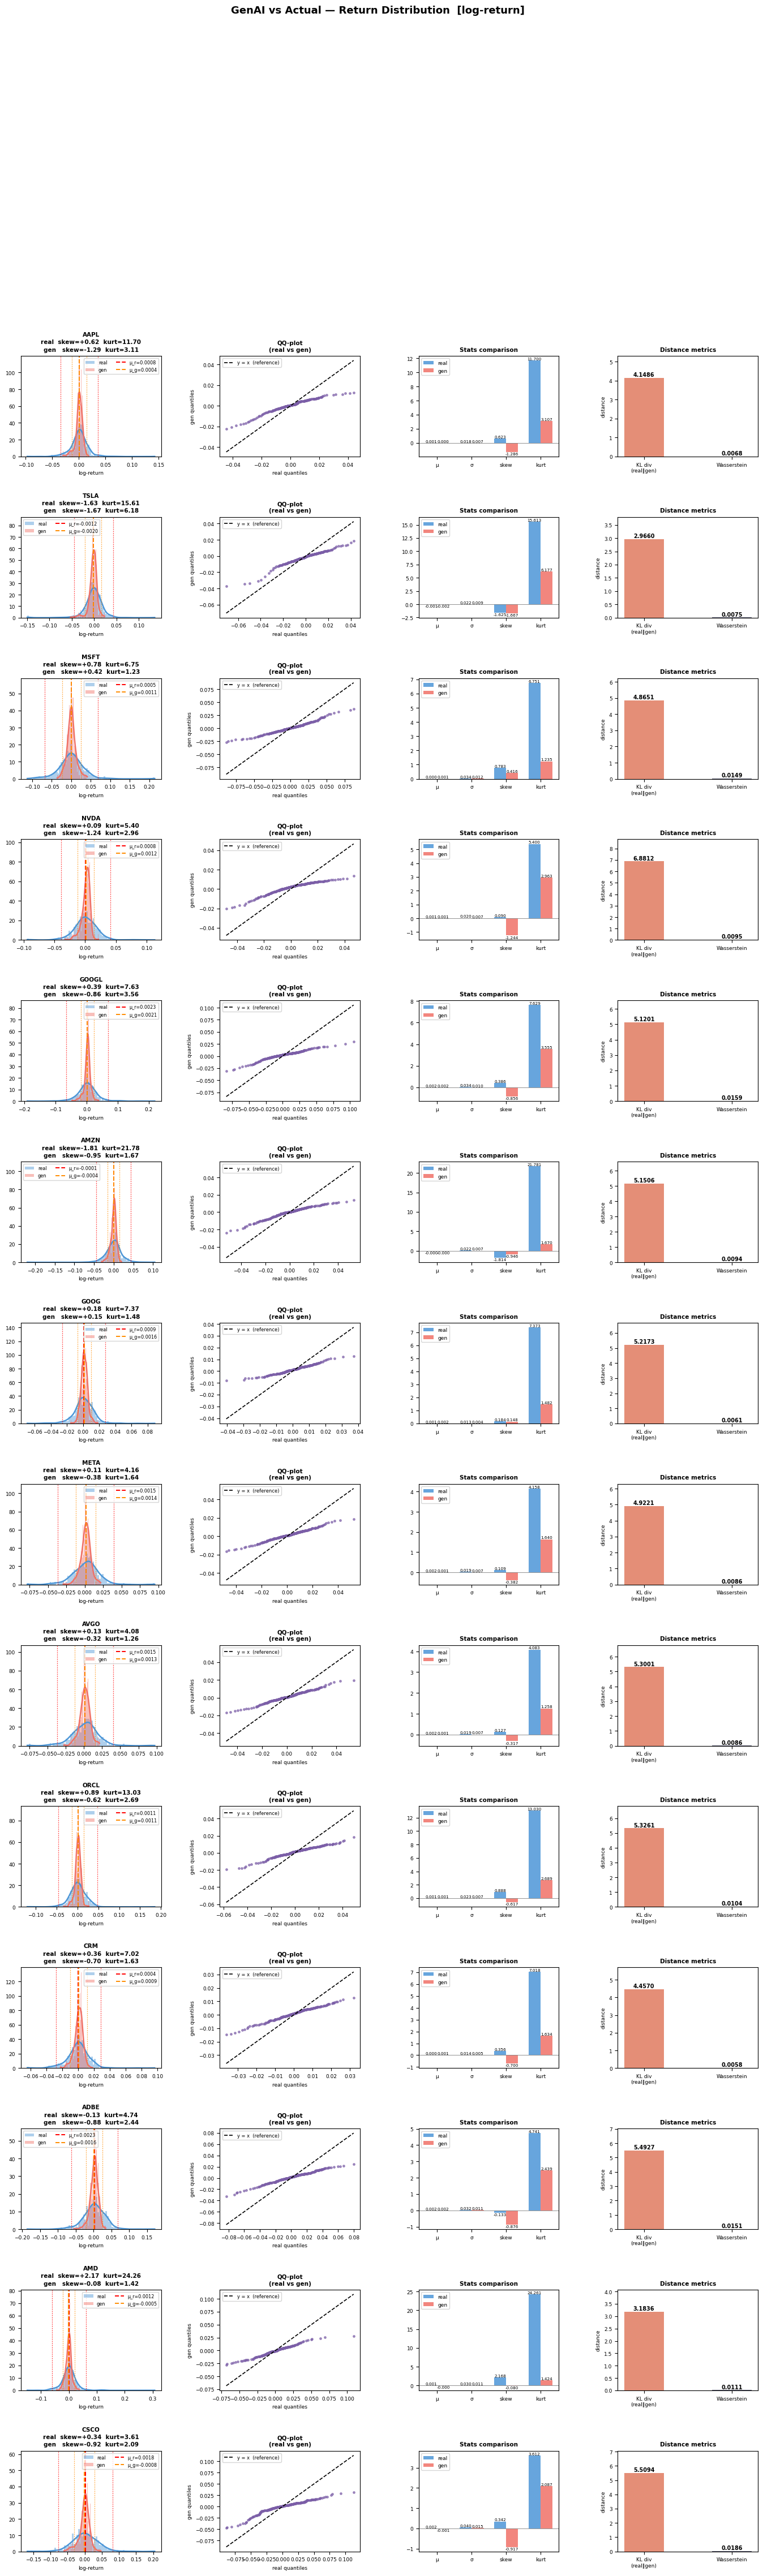

   dist_genai_vs_actual.png


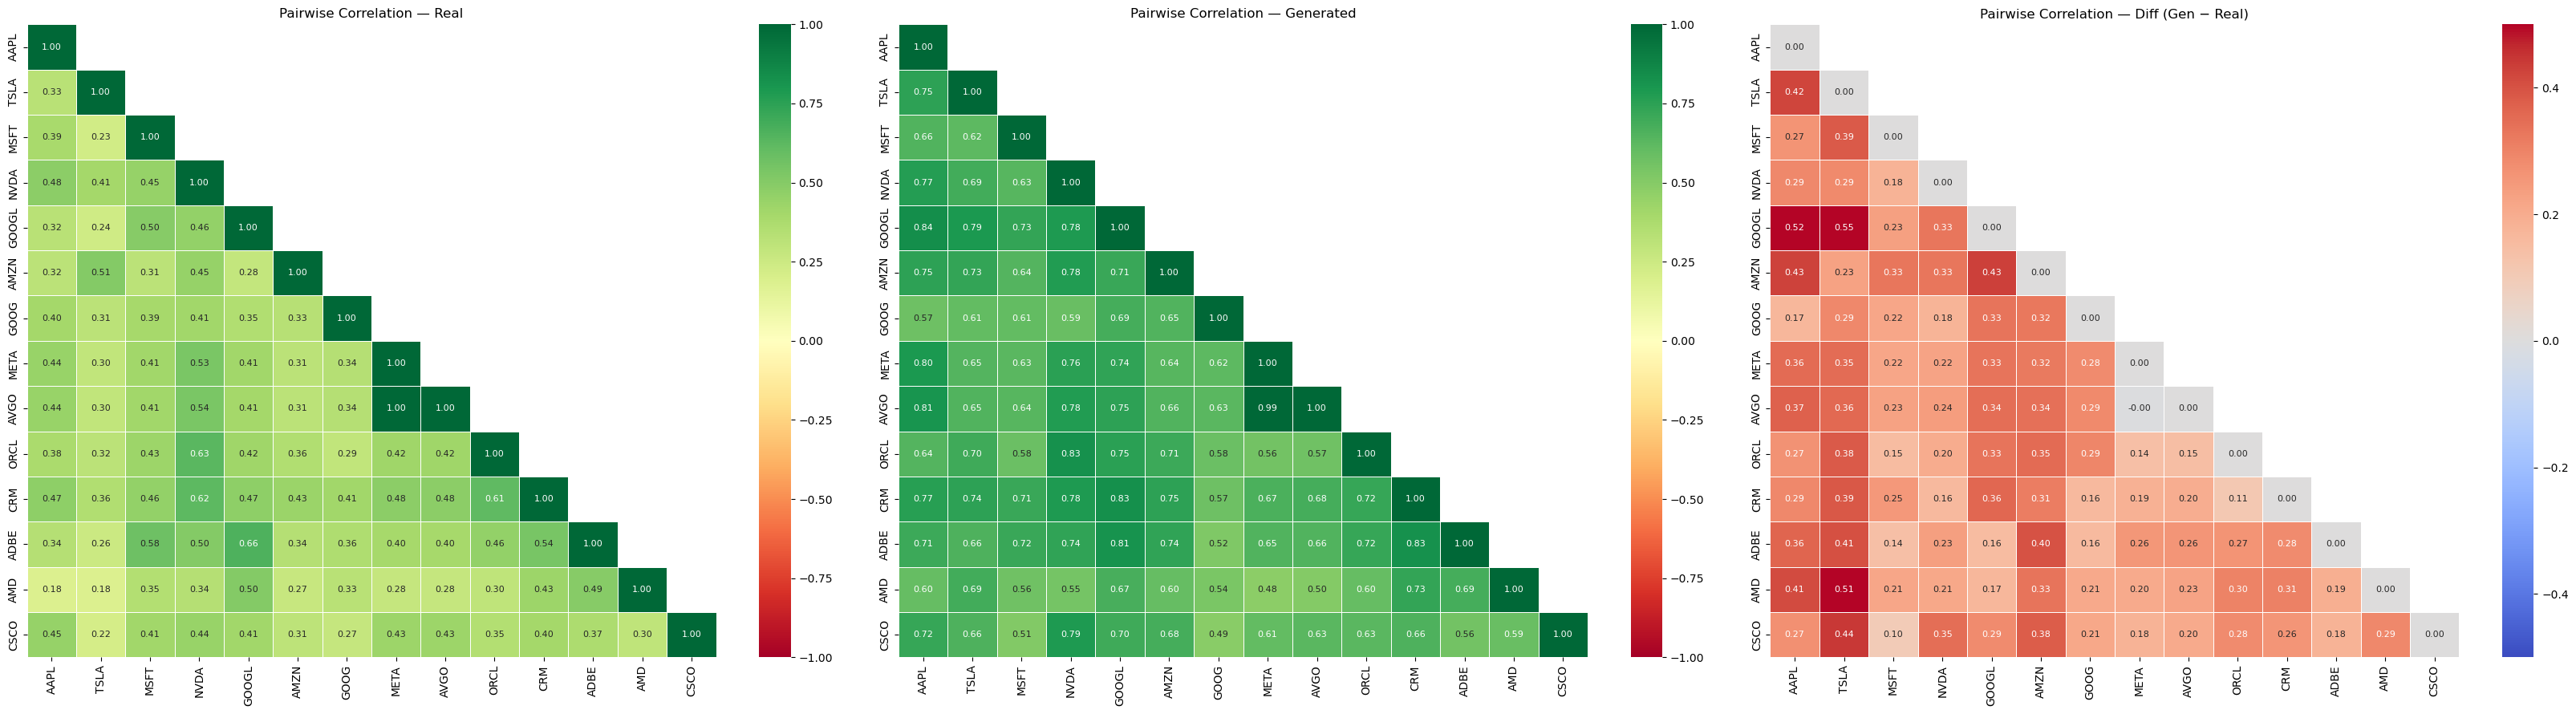


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.994,-0.004


   corr_genai_vs_actual.png


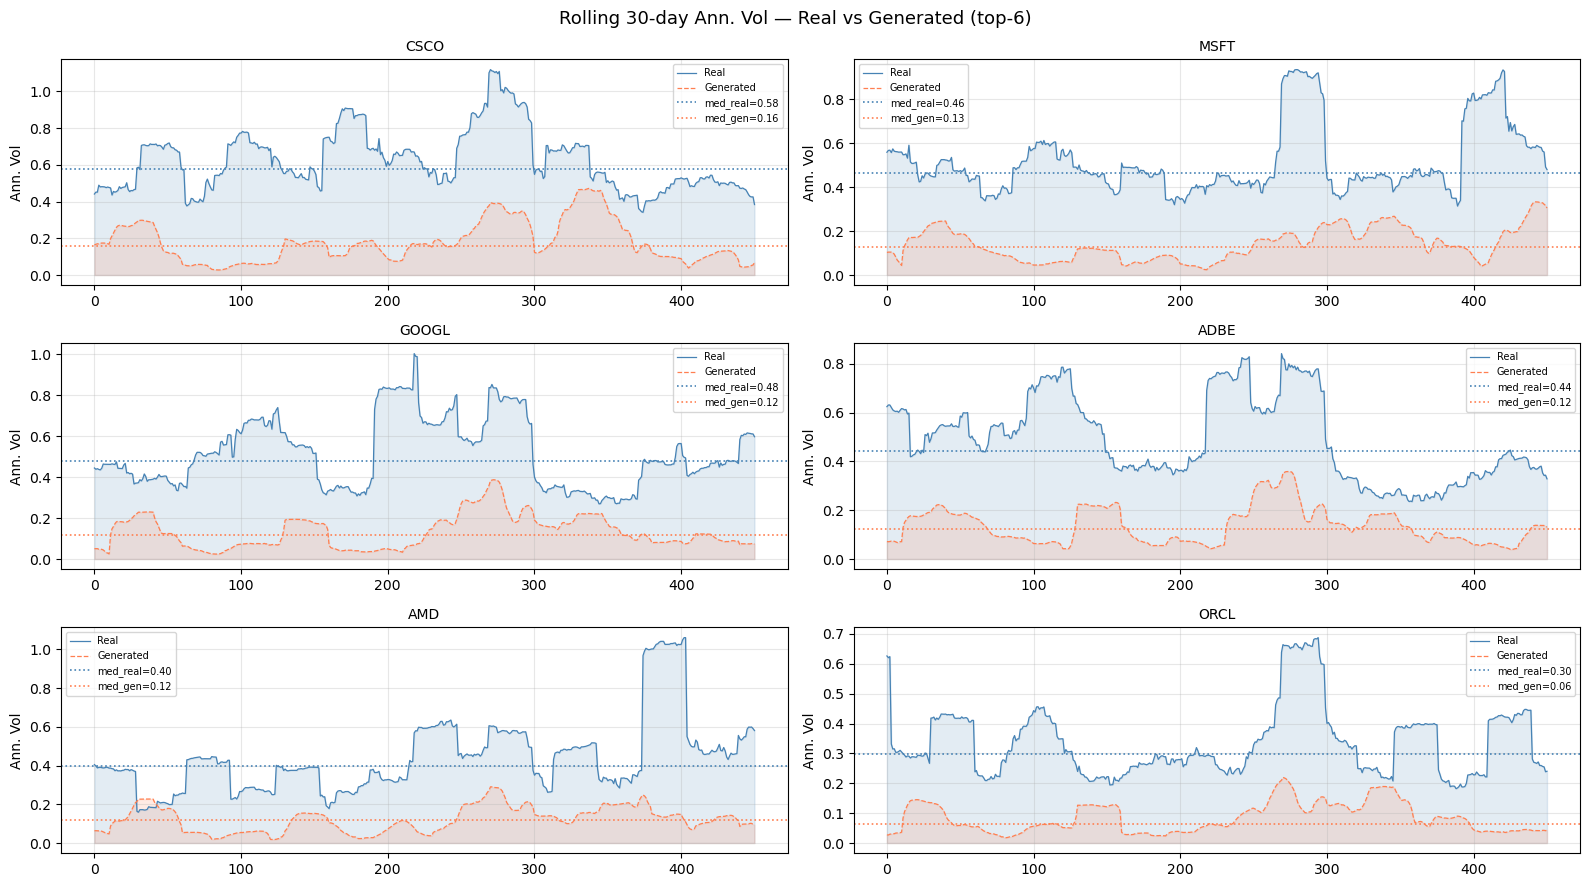

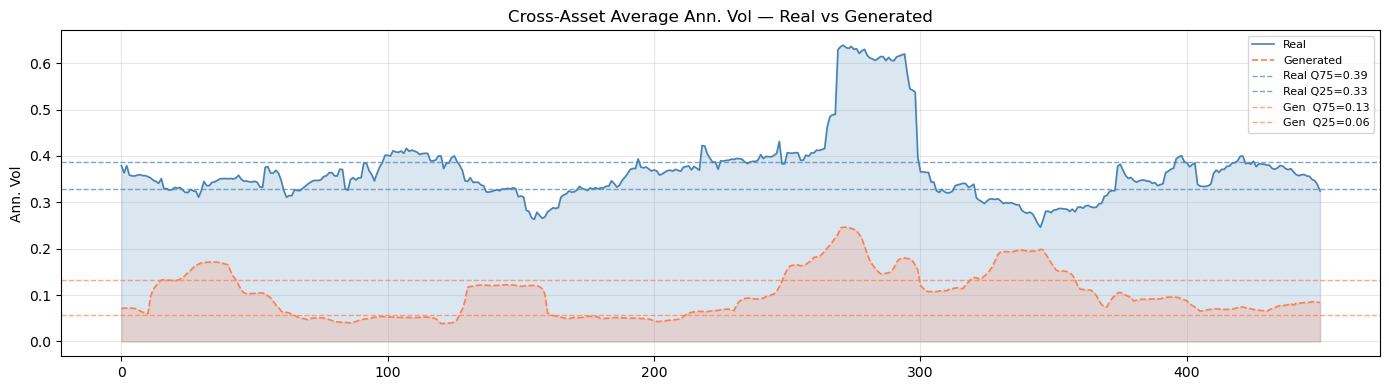

   vol_genai_vs_actual_per_asset.png
   vol_genai_vs_actual_avg.png


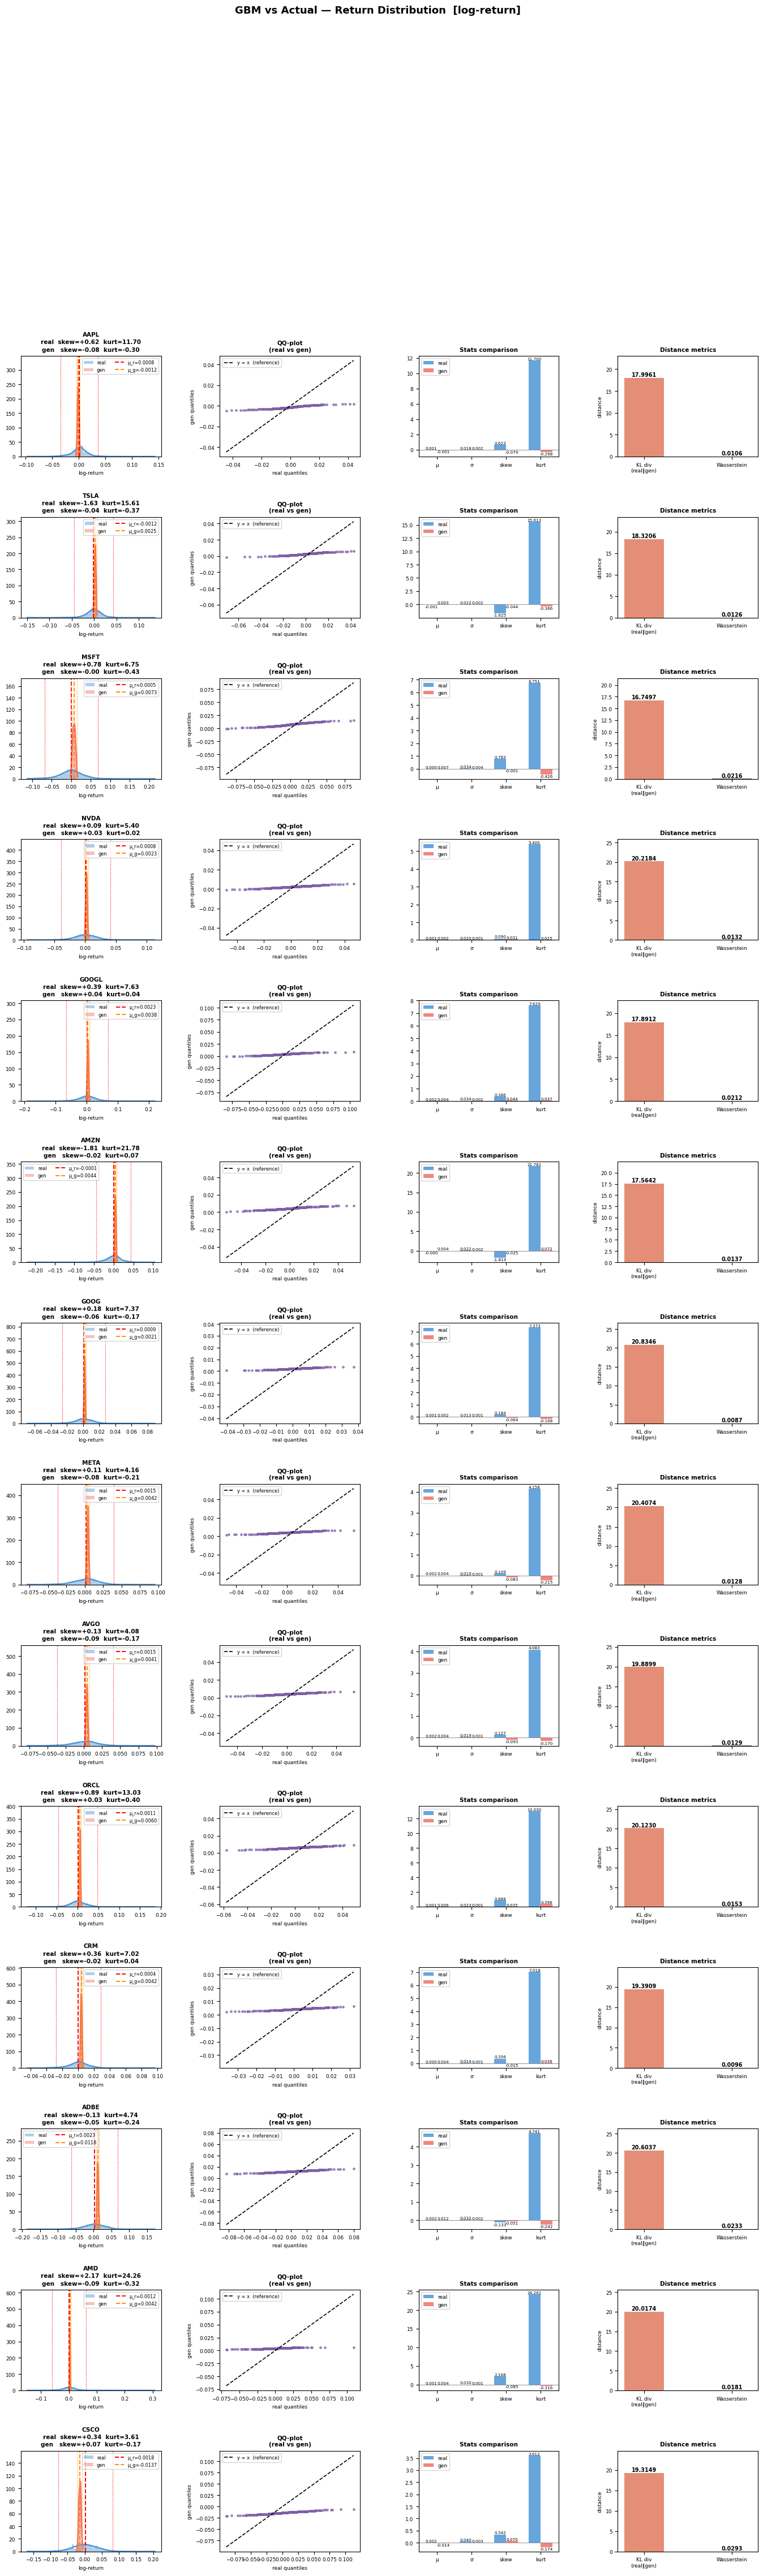

   dist_gbm_vs_actual.png


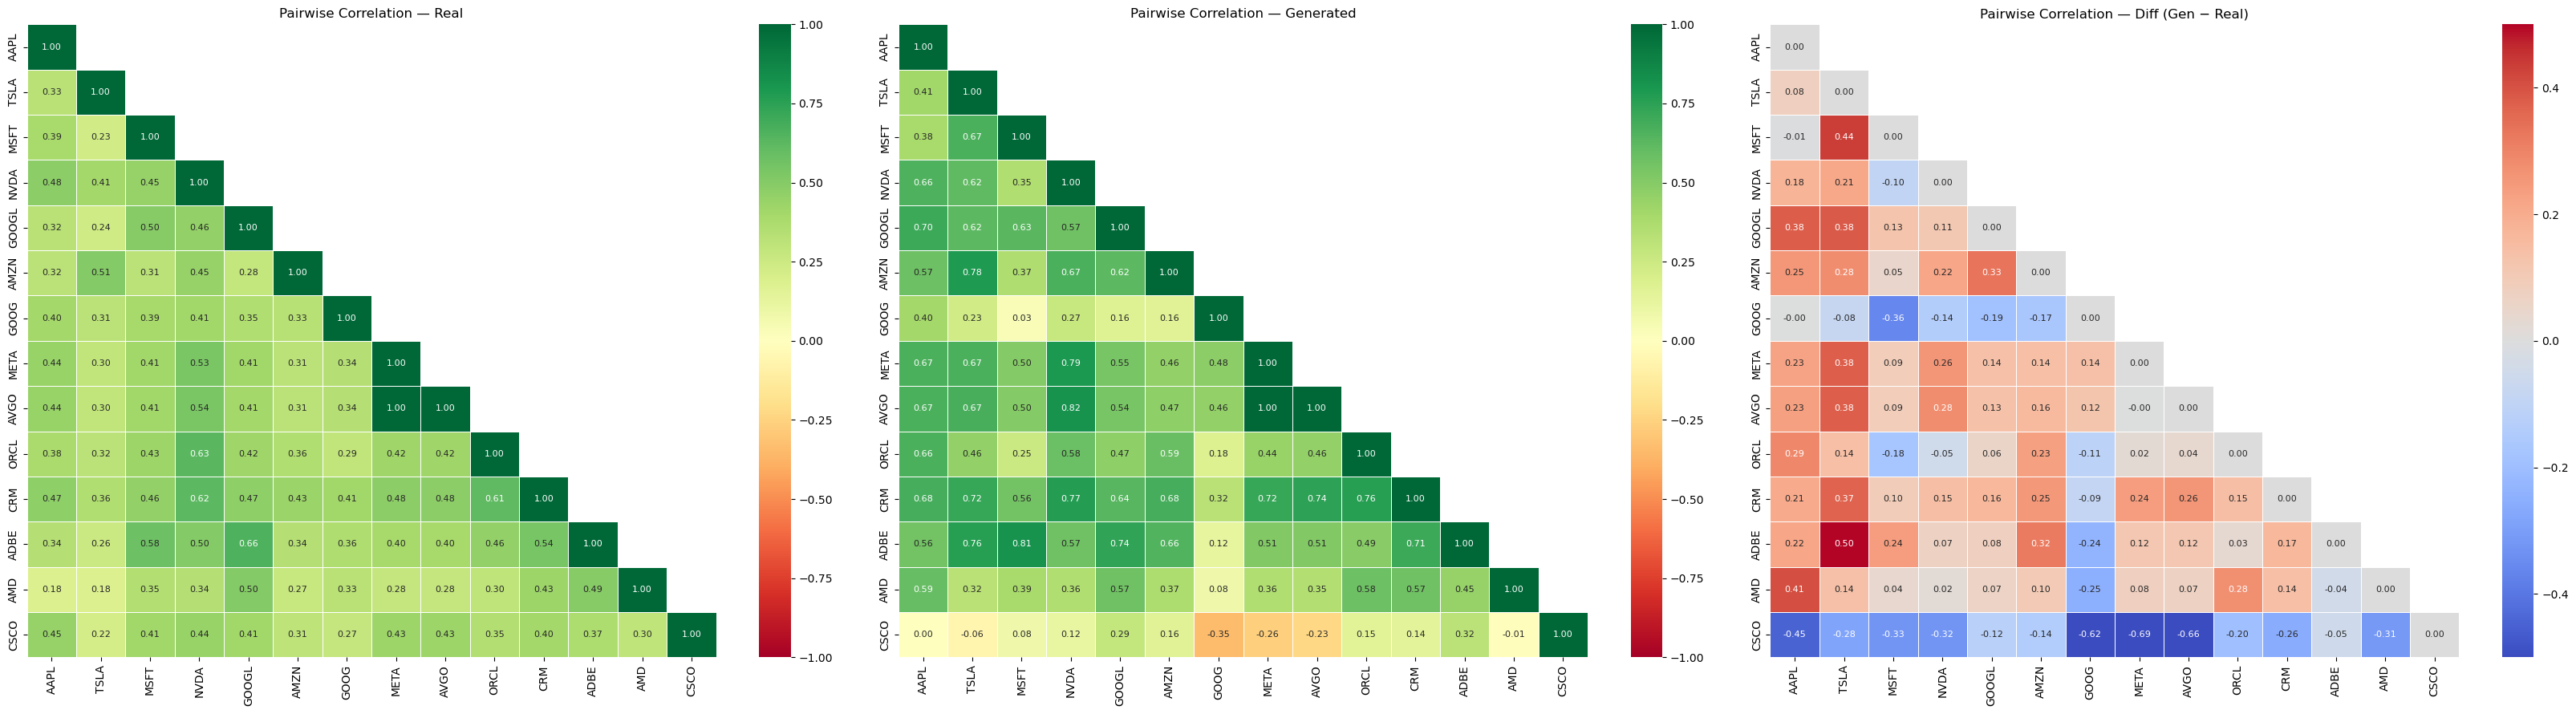


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.997,-0.001


   corr_gbm_vs_actual.png


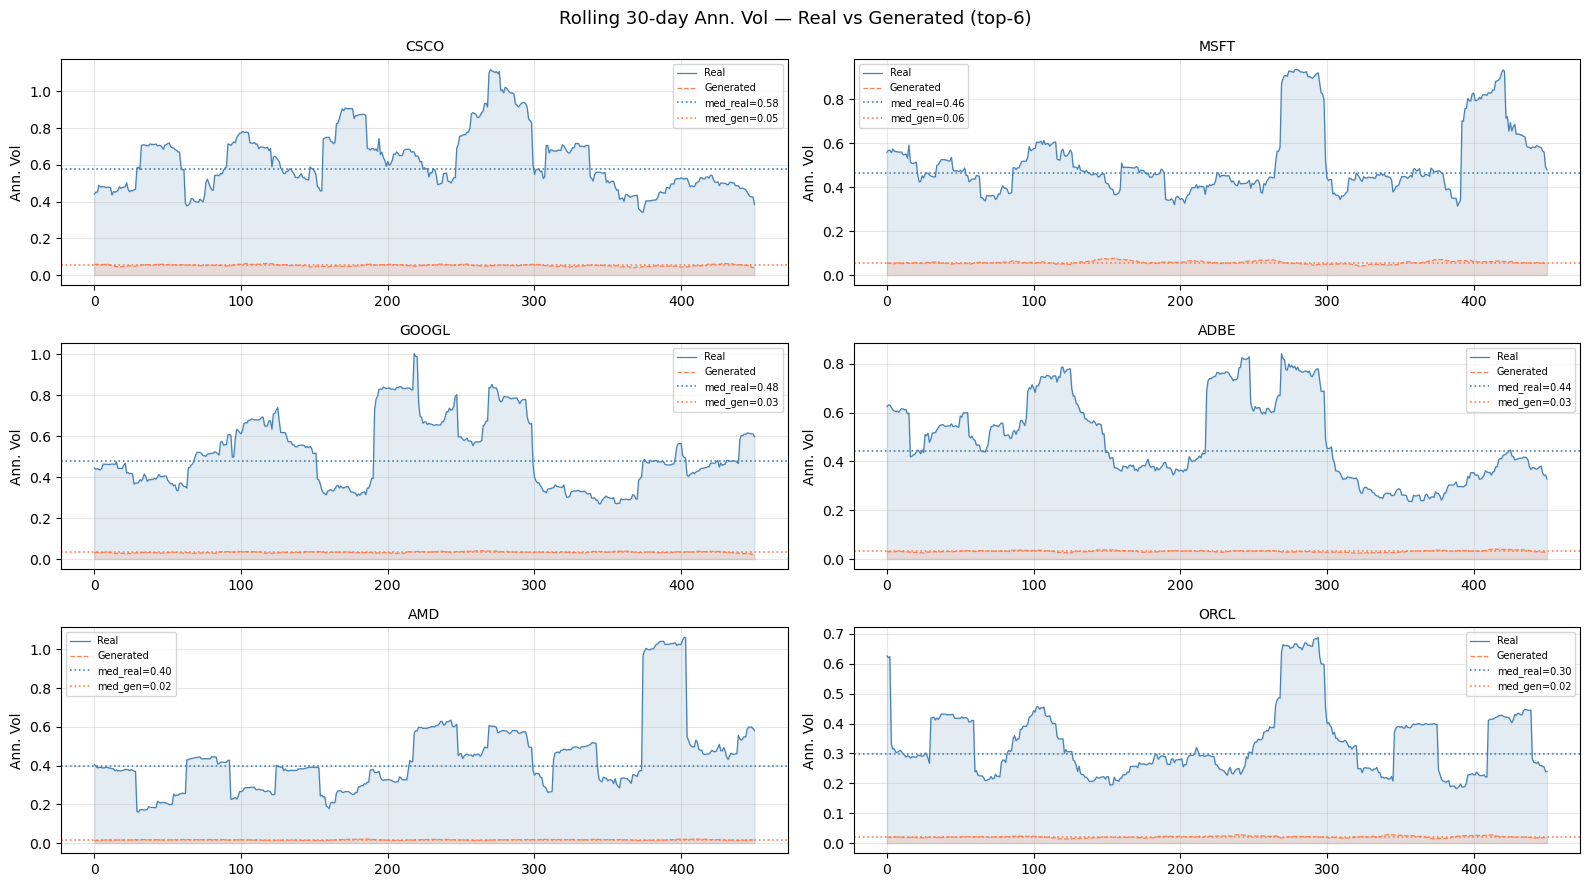

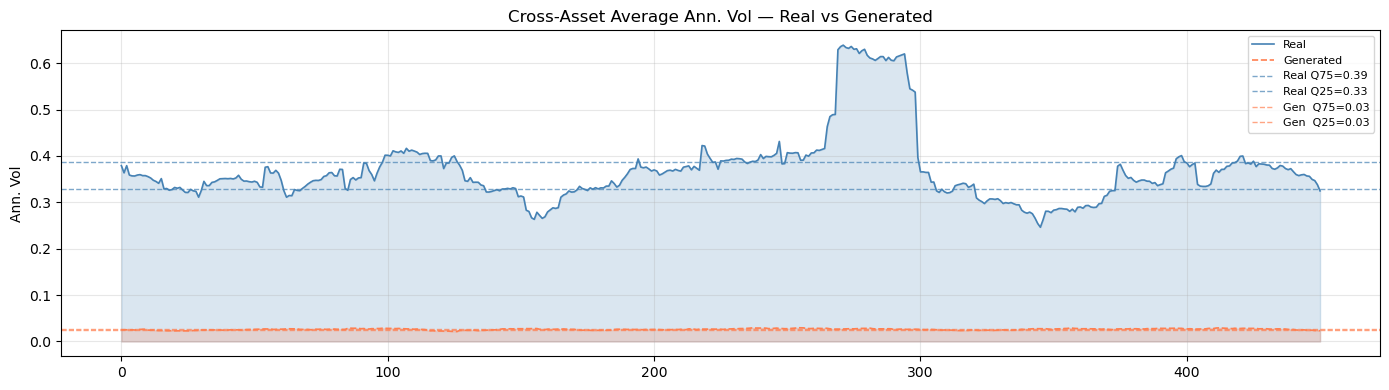

   vol_gbm_vs_actual_per_asset.png
   vol_gbm_vs_actual_avg.png


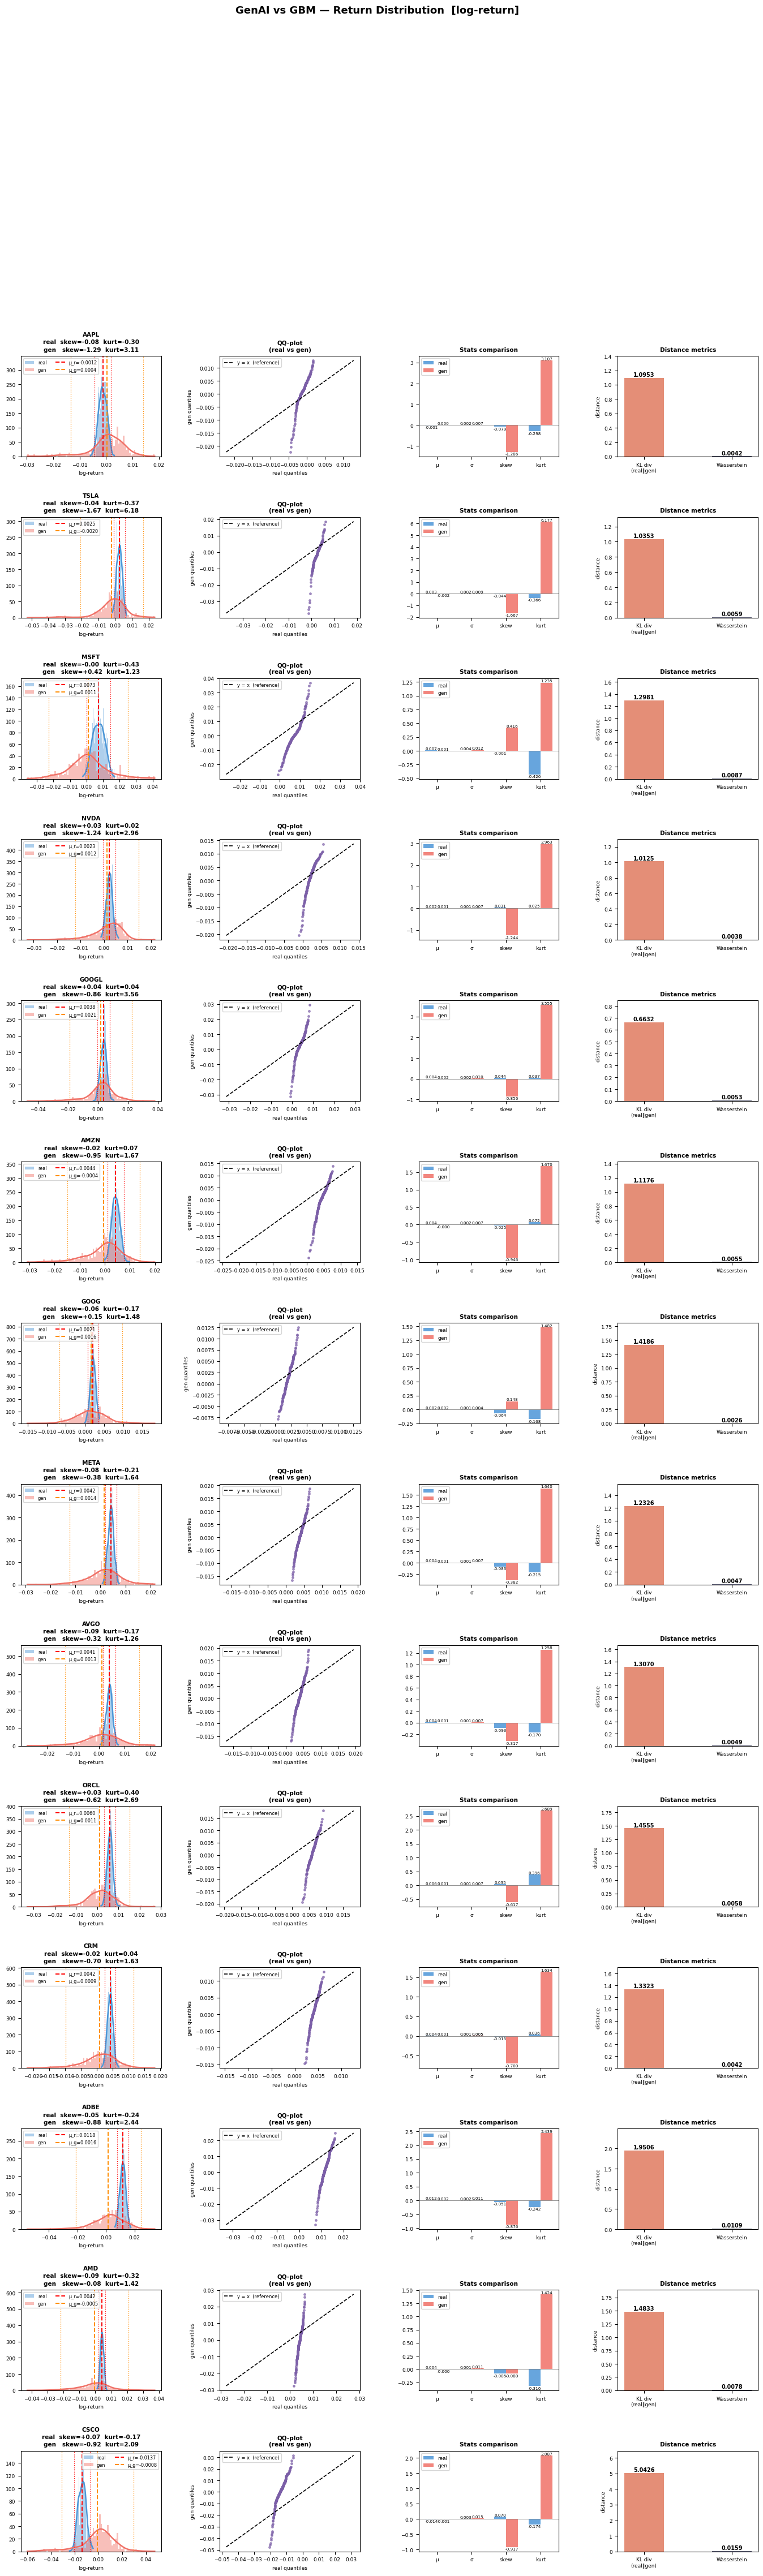

   dist_genai_vs_gbm.png


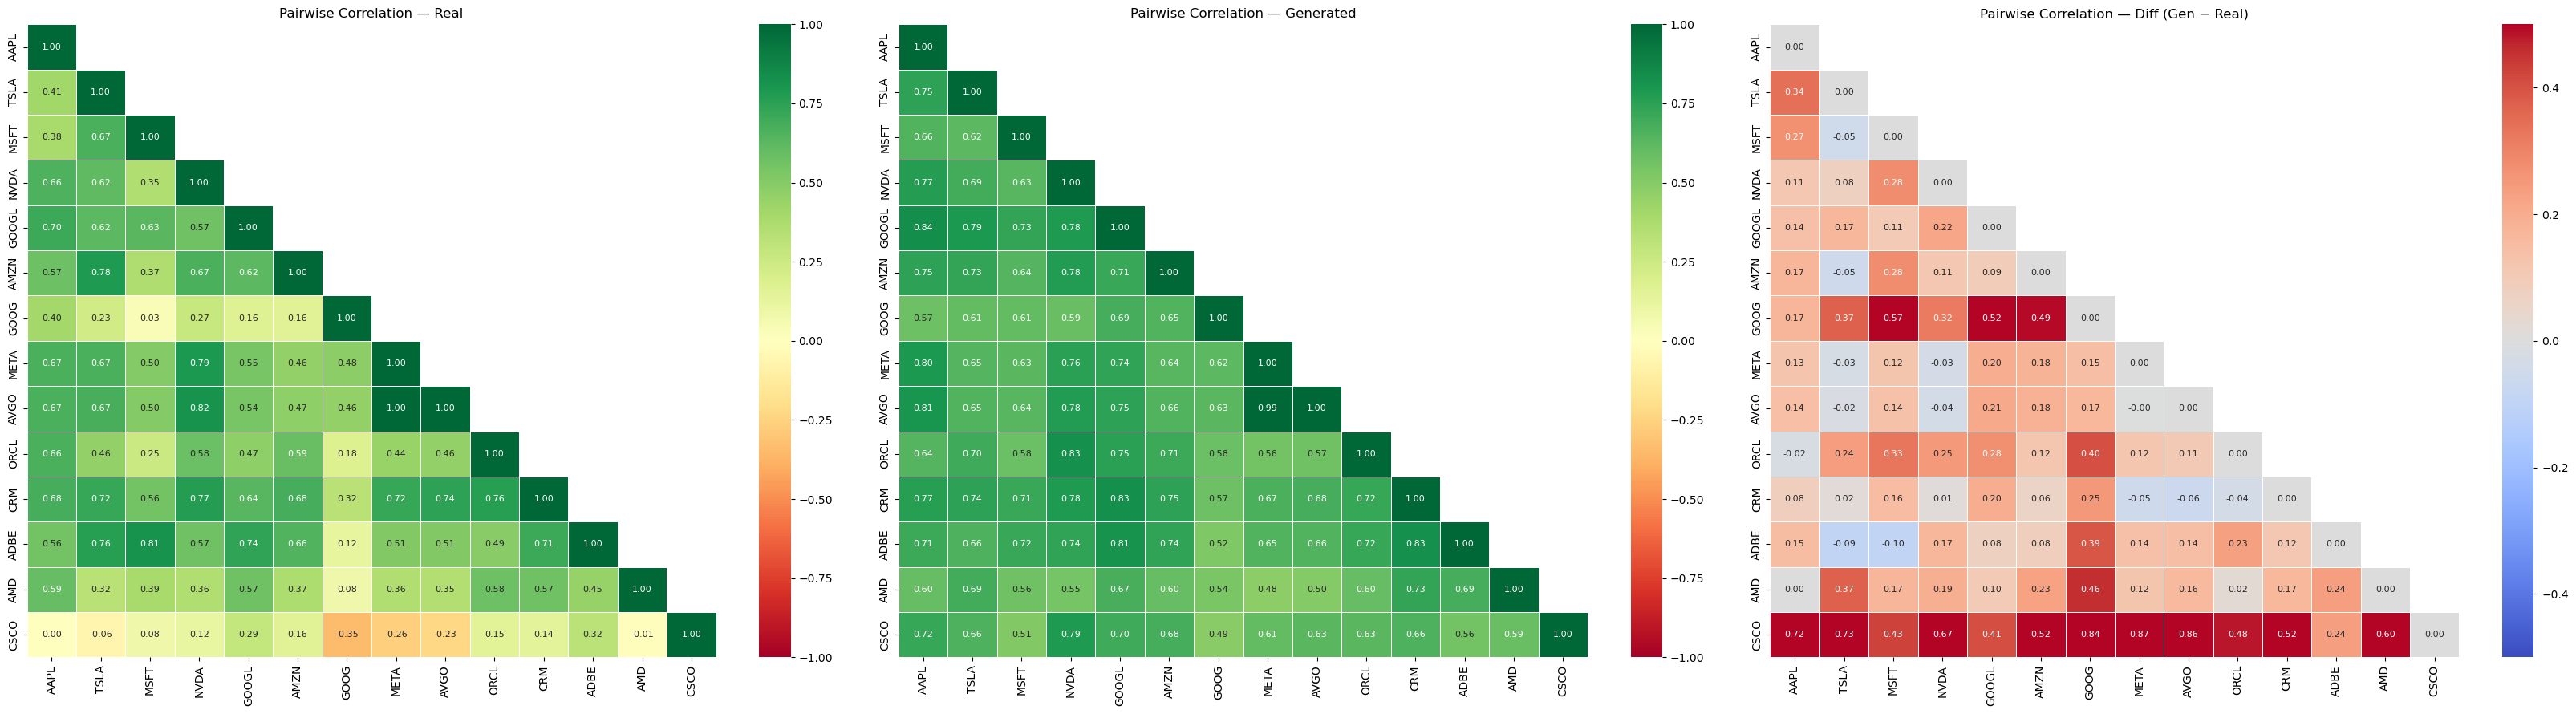


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.997,0.994,-0.004


   corr_genai_vs_gbm.png


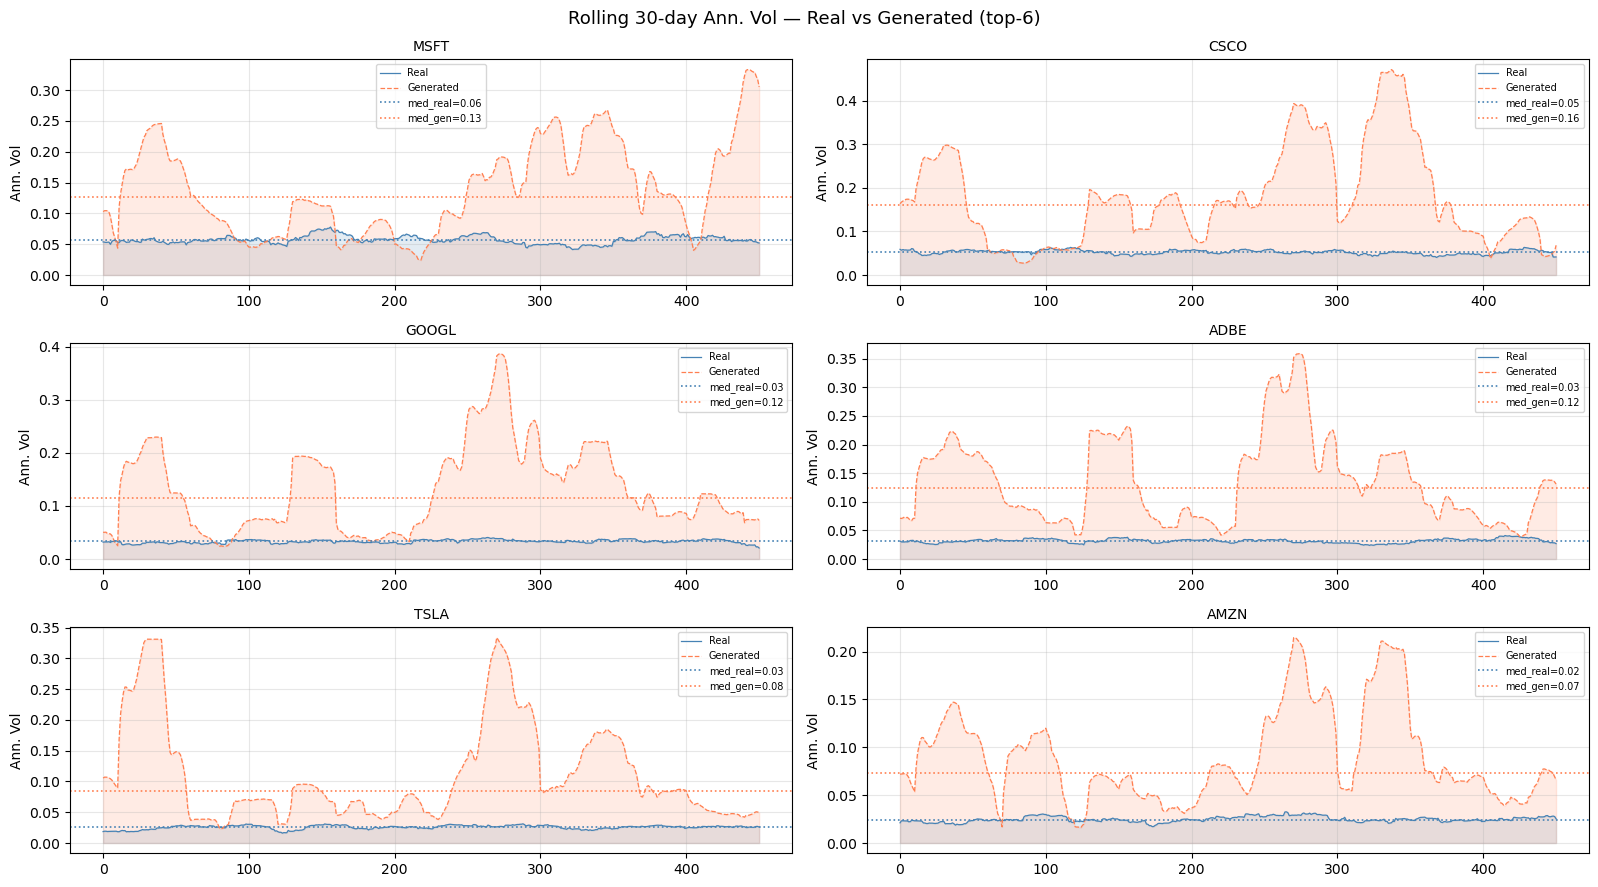

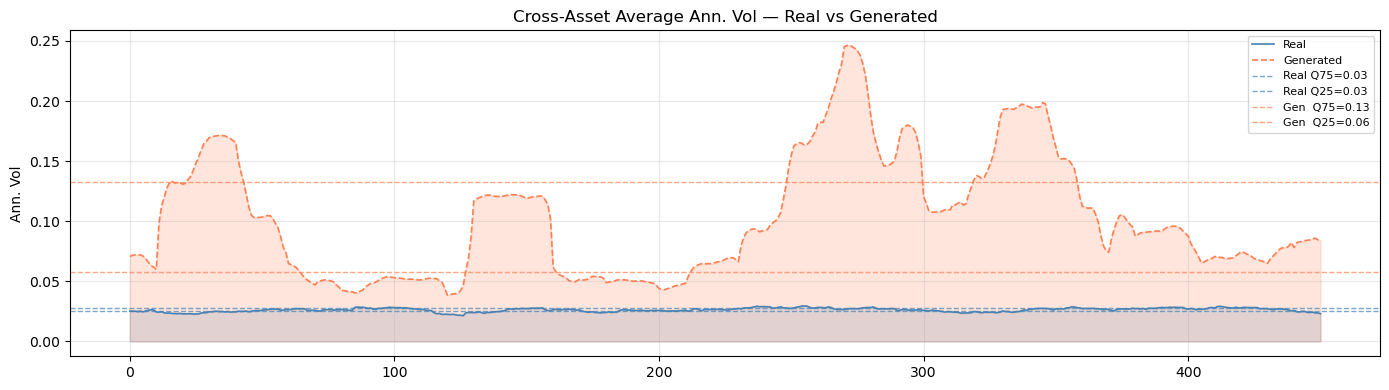

   vol_genai_vs_gbm_per_asset.png
   vol_genai_vs_gbm_avg.png
✅ R² plot saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/plots/r2_genai_vs_gbm.png

✅ All done! Structure:
   /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/
   ├── sim_results.npz
   ├── sim_meta.json
   ├── plots/
   │   ├── dist_*.png  (3 comparisons)
   │   ├── corr_*.png  (3 comparisons)
   │   └── vol_*.png   (3 x 2 = 6 files)
   └── reports/
       ├── actual_log_returns.csv
       ├── genai_mean_path.csv
       ├── gbm_mean_path.csv
       ├── genai_paths_all_paths.csv   (long format)
       ├── gbm_paths_all_paths.csv     (long format)
       └── metrics_comparison.csv


In [ ]:
symbols = config.feature.symbols

# ── Directory structure ───────────────────────────────────────────────────────
plots_dir   = sim_dir / "plots"
reports_dir = sim_dir / "reports"
plots_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# ── Prep shapes [T, A] ────────────────────────────────────────────────────────
actual_TA = actual_cat.T                  # [150, A]
genai_TA  = gen_cat.mean(axis=0).T       # [150, A]  mean across n_paths
gbm_TA    = gbm_paths.mean(axis=0).T     # [150, A]  mean across n_paths

flat_dates_dt = pd.to_datetime(dates.reshape(-1))   # [150]  datetime index

# ── 1. Save .npz ─────────────────────────────────────────────────────────────
npz_path = sim_dir / "sim_results.npz"
np.savez_compressed(
    npz_path,
    generated    = generated,
    actual       = actual,
    dates        = dates,
    close_prices = close_prices,
    x_prev_mean  = x_prev_mean,
    x_prev_std   = x_prev_std,
    x_prev       = x_prev,
    # aggregated (cat) versions
    actual_cat   = actual_cat,     # [A, 150]
    gen_cat      = gen_cat,        # [n_paths, A, 150]
    gbm_paths    = gbm_paths,      # [n_paths, A, 150]
)

sim_meta = {
    "exp_name"       : EXP_NAME,
    "checkpoint"     : CKPT_FILE,
    "processed_name" : config.processed_name,
    "date_start"     : dt_series[0].date().isoformat(),
    "date_end"       : dt_series[-1].date().isoformat(),
    "n_windows"      : int(generated.shape[0]),
    "n_paths"        : int(generated.shape[1]),
    "n_assets"       : int(generated.shape[2]),
    "window_size"    : int(generated.shape[3]),
    "channels"       : int(generated.shape[4]),
    "horizon"        : int(actual_TA.shape[0]),
    "symbols"        : symbols,
    "device"         : str(device),
}
with open(sim_dir / "sim_meta.json", "w") as f:
    json.dump(sim_meta, f, indent=4)

print(f"✅ npz saved  → {npz_path}")

# ── 2. CSV : mean paths (with date index) ─────────────────────────────────────
actual_df = pd.DataFrame(actual_TA, index=flat_dates_dt, columns=symbols)
genai_df  = pd.DataFrame(genai_TA,  index=flat_dates_dt, columns=symbols)
gbm_df    = pd.DataFrame(gbm_TA,    index=flat_dates_dt, columns=symbols)

actual_df.to_csv(reports_dir / "actual_log_returns.csv")
genai_df.to_csv(reports_dir  / "genai_mean_path.csv")
gbm_df.to_csv(reports_dir    / "gbm_mean_path.csv")
print(f"✅ mean path CSVs saved → {reports_dir}")

# ── 3. CSV : per-path (long format) ───────────────────────────────────────────
# gen_cat  : [n_paths, A, 150]
# gbm_paths: [n_paths, A, 150]
for name, arr in [("genai_paths", gen_cat), ("gbm_paths", gbm_paths)]:
    n_p, n_a, n_t = arr.shape
    records = []
    for p in range(n_p):
        df_p = pd.DataFrame(
            arr[p].T,                   # [150, A]
            index=flat_dates_dt,
            columns=symbols,
        )
        df_p.index.name = "date"
        df_p["path"] = p
        records.append(df_p.reset_index())
    pd.concat(records, ignore_index=True).to_csv(
        reports_dir / f"{name}_all_paths.csv", index=False
    )
print(f"✅ per-path CSVs saved → {reports_dir}")

# ── 4. Metrics table ──────────────────────────────────────────────────────────
def compute_metrics_df(ref_TA, pred_TA, pred_label, ref_label="Actual"):
    """ref_TA, pred_TA : [T, A]"""
    rows = []
    for i, sym in enumerate(symbols):
        r = ref_TA[:, i].astype(float)
        g = pred_TA[:, i].astype(float)
        r, g = r[np.isfinite(r)], g[np.isfinite(g)]
        min_len = min(len(r), len(g))
        mse = float(np.mean((r[:min_len] - g[:min_len]) ** 2))
        mae = float(np.mean(np.abs(r[:min_len] - g[:min_len])))
        kl  = _kl_divergence(r, g)
        wd  = float(wasserstein_distance(r, g))
        r2 = float(r2_score(r[:min_len], g[:min_len]))
        rows.append({
            "asset"                   : sym,
            f"MSE_{pred_label}"       : round(mse, 8),
            f"MAE_{pred_label}"       : round(mae, 8),
            f"KL_{pred_label}"        : round(kl,  6),
            f"Wasserstein_{pred_label}": round(wd,  6),
            f"R2_{pred_label}": round(r2, 6),
        })
    return pd.DataFrame(rows).set_index("asset")

metrics_genai = compute_metrics_df(actual_TA, genai_TA, "GenAI")
metrics_gbm   = compute_metrics_df(actual_TA, gbm_TA,   "GBM")
metrics_all   = pd.concat([metrics_genai, metrics_gbm], axis=1)
metrics_all.to_csv(reports_dir / "metrics_comparison.csv")
print(f"✅ metrics saved → {reports_dir / 'metrics_comparison.csv'}")
print(metrics_all.to_string())

# ── 5. Plots ──────────────────────────────────────────────────────────────────
def _save(fig, name):
    fig.savefig(plots_dir / name, bbox_inches="tight", dpi=120)
    plt.close(fig)
    print(f"   {name}")

print(f"\nSaving plots → {plots_dir}")

# GenAI vs Actual
fig, _ = plot_compare_dist(actual_TA, genai_TA, symbols,
                           title="GenAI vs Actual — Return Distribution")
_save(fig, "dist_genai_vs_actual.png")

fig, _, _ = plot_compare_correlation(actual_TA, genai_TA, symbols)
_save(fig, "corr_genai_vs_actual.png")

fig1, fig2 = plot_compare_rolling_vol(actual_TA, genai_TA, symbols)
_save(fig1, "vol_genai_vs_actual_per_asset.png")
_save(fig2, "vol_genai_vs_actual_avg.png")

# GBM vs Actual
fig, _ = plot_compare_dist(actual_TA, gbm_TA, symbols,
                           title="GBM vs Actual — Return Distribution")
_save(fig, "dist_gbm_vs_actual.png")

fig, _, _ = plot_compare_correlation(actual_TA, gbm_TA, symbols)
_save(fig, "corr_gbm_vs_actual.png")

fig1, fig2 = plot_compare_rolling_vol(actual_TA, gbm_TA, symbols)
_save(fig1, "vol_gbm_vs_actual_per_asset.png")
_save(fig2, "vol_gbm_vs_actual_avg.png")

# GenAI vs GBM
fig, _ = plot_compare_dist(gbm_TA, genai_TA, symbols,
                           title="GenAI vs GBM — Return Distribution")
_save(fig, "dist_genai_vs_gbm.png")

fig, _, _ = plot_compare_correlation(gbm_TA, genai_TA, symbols)
_save(fig, "corr_genai_vs_gbm.png")

fig1, fig2 = plot_compare_rolling_vol(gbm_TA, genai_TA, symbols)
_save(fig1, "vol_genai_vs_gbm_per_asset.png")
_save(fig2, "vol_genai_vs_gbm_avg.png")

# ── plot R² bar chart หลัง compute metrics ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(symbols))
width  = 0.35

ax.bar(x - width/2, metrics_genai["R2_GenAI"], width,
       color="#4C96D7", alpha=0.85, label="GenAI")
ax.bar(x + width/2, metrics_gbm["R2_GBM"],   width,
       color="#F07167", alpha=0.85, label="GBM")

ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.axhline(1, color="grey",  lw=0.8, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(symbols, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("R² Score")
ax.set_title("R² Score per Asset — GenAI vs GBM (vs Actual)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig.savefig(plots_dir / "r2_genai_vs_gbm.png", bbox_inches="tight", dpi=120)
plt.close(fig)
print(f"✅ R² plot saved → {plots_dir / 'r2_genai_vs_gbm.png'}")

print(f"\n✅ All done! Structure:")
print(f"   {sim_dir}/")
print(f"   ├── sim_results.npz")
print(f"   ├── sim_meta.json")
print(f"   ├── plots/")
print(f"   │   ├── dist_*.png  (3 comparisons)")
print(f"   │   ├── corr_*.png  (3 comparisons)")
print(f"   │   └── vol_*.png   (3 x 2 = 6 files)")
print(f"   └── reports/")
print(f"       ├── actual_log_returns.csv")
print(f"       ├── genai_mean_path.csv")
print(f"       ├── gbm_mean_path.csv")
print(f"       ├── genai_paths_all_paths.csv   (long format)")
print(f"       ├── gbm_paths_all_paths.csv     (long format)")
print(f"       └── metrics_comparison.csv")

In [ ]:
import shutil

shutil.copy(
    exp_dir / "config.json",
    sim_dir / "config.json",
)
print(f"✅ config.json copied → {sim_dir / 'config.json'}")

✅ config.json copied → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/config.json


In [ ]:
def plot_forecast_analysis(
    asset_idx: int,
    gen_cat: np.ndarray,        # [n_paths, A, horizon]  log-returns
    actual_cat: np.ndarray,     # [A, horizon]           log-returns
    gbm_paths: np.ndarray,      # [n_paths, A, horizon]  log-returns
    close_prices: np.ndarray,   # [N_windows, T, A]
    symbols: list,
    plots_dir: Path = None,
    dpi: int = 150,
    alpha_paths: float = 0.08,
    n_paths_display: int = None,  # None = แสดงทุก path, หรือระบุจำนวน
):
    """
    สร้าง 2 plots ต่อ asset:
      1. forecast_logret_<symbol>.png   — log returns
      2. forecast_price_<symbol>.png    — price (base × exp(cumsum))

    แสดง:
      - actual history ทั้งหมด (เส้นหนาเขียว)
      - forecast fan: แต่ละ path (จาง) + mean + percentile band (10-90)
      - ground truth ใน forecast zone (เส้นเขียวซ้อนบน fan)
    """
    sym     = symbols[asset_idx]
    n_paths = gen_cat.shape[0]
    horizon = actual_cat.shape[1]

    # จำกัด paths ที่แสดง (ถ้าเยอะเกิน)
    n_show = n_paths if n_paths_display is None else min(n_paths_display, n_paths)
    idx_show = np.linspace(0, n_paths - 1, n_show, dtype=int)

    # ── log-return arrays ────────────────────────────────────────────────────
    act_lr = actual_cat[asset_idx]
    gen_lr = gen_cat[:, asset_idx, :]
    gbm_lr = gbm_paths[:, asset_idx, :]

    ctx_x = np.arange(horizon)
    fct_x = np.arange(horizon - 1, 2 * horizon)

    anchor_lr  = act_lr[-1]
    gen_fan    = np.concatenate([np.full((n_paths, 1), anchor_lr), gen_lr], axis=1)
    gbm_fan    = np.concatenate([np.full((n_paths, 1), anchor_lr), gbm_lr], axis=1)
    act_fct_lr = np.concatenate([[anchor_lr], act_lr])

    # stats: mean + percentile band
    gen_mean = gen_fan.mean(axis=0)
    gbm_mean = gbm_fan.mean(axis=0)
    gen_p10, gen_p90 = np.percentile(gen_fan, [10, 90], axis=0)
    gbm_p10, gbm_p90 = np.percentile(gbm_fan, [10, 90], axis=0)

    # ── price arrays ─────────────────────────────────────────────────────────
    base_price = float(close_prices[-1, -1, asset_idx])

    def to_price(lr):
        return base_price * np.exp(np.cumsum(lr, axis=-1))

    act_price_full = np.concatenate([[base_price], to_price(act_lr)])
    ctx_price_x    = np.arange(len(act_price_full))

    gen_price_fan  = np.concatenate([np.full((n_paths, 1), base_price), to_price(gen_lr)], axis=1)
    gbm_price_fan  = np.concatenate([np.full((n_paths, 1), base_price), to_price(gbm_lr)], axis=1)
    act_price_fct  = np.concatenate([[base_price], to_price(act_lr)])
    fct_price_x    = np.arange(horizon, horizon + gen_price_fan.shape[1])

    gen_price_mean = gen_price_fan.mean(axis=0)
    gbm_price_mean = gbm_price_fan.mean(axis=0)
    gen_price_p10, gen_price_p90 = np.percentile(gen_price_fan, [10, 90], axis=0)
    gbm_price_p10, gbm_price_p90 = np.percentile(gbm_price_fan, [10, 90], axis=0)

    # ── helper ───────────────────────────────────────────────────────────────
    def _draw(ax, ctx_x, ctx_y, fct_x,
              gen_fan, gbm_fan,
              gen_mean, gbm_mean,
              gen_p10, gen_p90,
              gbm_p10, gbm_p90,
              act_fct, ylabel, title):

        # actual history
        ax.plot(ctx_x, ctx_y, color="#2ecc71", lw=2, zorder=5,
                label="Ground Truth (history)")
        # forecast boundary
        ax.axvline(ctx_x[-1], color="grey", lw=0.9, ls=":", alpha=0.7)

        # individual paths (จาง)
        for p in idx_show:
            ax.plot(fct_x, gen_fan[p], color="#e74c3c",
                    alpha=alpha_paths, lw=0.6)
            ax.plot(fct_x, gbm_fan[p], color="#3498db",
                    alpha=alpha_paths, lw=0.6)

        # percentile band (10-90)
        ax.fill_between(fct_x, gen_p10, gen_p90,
                        color="#e74c3c", alpha=0.15, label="GenAI (10-90%)")
        ax.fill_between(fct_x, gbm_p10, gbm_p90,
                        color="#3498db", alpha=0.15, label="GBM (10-90%)")

        # mean lines
        ax.plot(fct_x, gen_mean, color="#c0392b", lw=2.0, ls="--",
                label="GenAI (mean)", zorder=6)
        ax.plot(fct_x, gbm_mean, color="#2980b9", lw=2.0, ls="--",
                label="GBM (mean)", zorder=6)

        # ground truth ใน forecast zone
        ax.plot(fct_x, act_fct, color="#27ae60", lw=2.0, ls="-",
                marker="o", markersize=3, zorder=7, alpha=0.85,
                label="Ground Truth (forecast zone)")

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Time Step")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8, loc="best")
        ax.grid(alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)

    # ── Plot 1: log returns ───────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(14, 5))
    _draw(ax1, ctx_x, act_lr, fct_x,
          gen_fan, gbm_fan, gen_mean, gbm_mean,
          gen_p10, gen_p90, gbm_p10, gbm_p90,
          act_fct_lr,
          ylabel="Log Returns",
          title=f"{sym} — Forecast Analysis (Log Return)")
    fig1.tight_layout()

    # ── Plot 2: price ─────────────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(14, 5))
    _draw(ax2, ctx_price_x, act_price_full, fct_price_x,
          gen_price_fan, gbm_price_fan, gen_price_mean, gbm_price_mean,
          gen_price_p10, gen_price_p90, gbm_price_p10, gbm_price_p90,
          act_price_fct,
          ylabel="Price (USD)",
          title=f"{sym} — Forecast Analysis (Price)")
    fig2.tight_layout()

    # ── Save ──────────────────────────────────────────────────────────────────
    if plots_dir is not None:
        plots_dir = Path(plots_dir)
        plots_dir.mkdir(parents=True, exist_ok=True)
        p1 = plots_dir / f"forecast_logret_{sym}.png"
        p2 = plots_dir / f"forecast_price_{sym}.png"
        fig1.savefig(p1, dpi=dpi, bbox_inches="tight")
        fig2.savefig(p2, dpi=dpi, bbox_inches="tight")
        plt.close(fig1)
        plt.close(fig2)
        print(f"  {sym}  →  {p1.name}  |  {p2.name}")
    else:
        plt.show()

    return fig1, fig2


def plot_forecast_all_assets(
    gen_cat, actual_cat, gbm_paths, close_prices, symbols,
    plots_dir, dpi=150, alpha_paths=0.08, n_paths_display=None,
):
    """Loop ทุก asset แล้ว save ทั้งหมด"""
    for i in range(len(symbols)):
        plot_forecast_analysis(
            asset_idx       = i,
            gen_cat         = gen_cat,
            actual_cat      = actual_cat,
            gbm_paths       = gbm_paths,
            close_prices    = close_prices,
            symbols         = symbols,
            plots_dir       = plots_dir,
            dpi             = dpi,
            alpha_paths     = alpha_paths,
            n_paths_display = n_paths_display,
        )
    print(f"\n✅ All {len(symbols)} assets saved → {plots_dir}")

In [ ]:
plot_forecast_all_assets(
    gen_cat      = gen_cat,
    actual_cat   = actual_cat,
    gbm_paths    = gbm_paths,
    close_prices = close_prices,
    symbols      = symbols,
    plots_dir    = plots_dir / "forecast",
    alpha_paths  = 0.08,
    n_paths_display = None,
)

  AAPL  →  forecast_logret_AAPL.png  |  forecast_price_AAPL.png
  TSLA  →  forecast_logret_TSLA.png  |  forecast_price_TSLA.png
  MSFT  →  forecast_logret_MSFT.png  |  forecast_price_MSFT.png
  NVDA  →  forecast_logret_NVDA.png  |  forecast_price_NVDA.png
  GOOGL  →  forecast_logret_GOOGL.png  |  forecast_price_GOOGL.png
  AMZN  →  forecast_logret_AMZN.png  |  forecast_price_AMZN.png
  GOOG  →  forecast_logret_GOOG.png  |  forecast_price_GOOG.png
  META  →  forecast_logret_META.png  |  forecast_price_META.png
  AVGO  →  forecast_logret_AVGO.png  |  forecast_price_AVGO.png
  ORCL  →  forecast_logret_ORCL.png  |  forecast_price_ORCL.png
  CRM  →  forecast_logret_CRM.png  |  forecast_price_CRM.png
  ADBE  →  forecast_logret_ADBE.png  |  forecast_price_ADBE.png
  AMD  →  forecast_logret_AMD.png  |  forecast_price_AMD.png
  CSCO  →  forecast_logret_CSCO.png  |  forecast_price_CSCO.png

✅ All 14 assets saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_

## 9. Inverse Transform Comparison — Case 1 vs Case 2a vs Case 2b

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Inverse Transform Comparison
#
# actual / generated ณ จุดนี้ถูก inverse transform ด้วย per-window μₙ σₙ ไปแล้ว
# (Case 1) ดังนั้นเพื่อทำ Case 2a/2b ต้อง re-normalize กลับก่อน
# แล้วค่อย inverse transform ใหม่ด้วย fixed scaler
#
# Case 1  (per-window)  : ใช้ μₙ σₙ from x_prev[n]  — gen_cat / actual_cat เดิม
#                          ⚠ leak: รู้ GT stats ทุก window  ✅ per-window quality
# Case 2a (fixed μ₀σ₀)  : fixed จาก x_prev[0] ของ test  ✅ no leak
# Case 2b (train mean)  : fixed จาก mean of train x_prev  ✅ no leak, stable
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd

# ── Step 1: re-normalize actual / generated กลับไป normalized space ─────────
# actual    : [N, A, T, C]          (denorm แล้ว ด้วย μₙ σₙ)
# generated : [N, n_paths, A, T, C] (denorm แล้ว ด้วย μₙ σₙ)
mu_n  = x_prev_mean[:, :, 0]                              # [N, A]
std_n = x_prev_std[:, :, 0]                               # [N, A]
mu_n_a  = mu_n[:, :, np.newaxis, np.newaxis]              # [N, A, 1, 1]
std_n_a = std_n[:, :, np.newaxis, np.newaxis]
mu_n_g  = mu_n[:, np.newaxis, :, np.newaxis, np.newaxis]  # [N, 1, A, 1, 1]
std_n_g = std_n[:, np.newaxis, :, np.newaxis, np.newaxis]

actual_renorm    = (actual - mu_n_a) / std_n_a            # [N, A, T, C]
generated_renorm = (generated - mu_n_g) / std_n_g         # [N, n_paths, A, T, C]

print('Re-normalize done ✅')
print(f'  actual_renorm    std (ควร ≈ 1.0): {actual_renorm[:,:,:,0].std():.4f}')
print(f'  generated_renorm std            : {generated_renorm[:,:,:,:,0].std():.4f}')

# ── Step 2: Scalers ──────────────────────────────────────────────────────────
MU_2A  = x_prev_mean[0, :, 0]                                    # [A]  test window 0
STD_2A = x_prev_std[0, :, 0]                                     # [A]
MU_2B  = parts['train']['x_prev_mean'][1:, :, 0].mean(axis=0)    # [A]  mean train (skip NaN)
STD_2B = parts['train']['x_prev_std'][1:, :, 0].mean(axis=0)     # [A]

print(f'\nScalers (first 3 assets):')
print(f'  Case 2a  μ : {MU_2A[:3].round(6)}   σ : {STD_2A[:3].round(6)}')
print(f'  Case 2b  μ : {MU_2B[:3].round(6)}   σ : {STD_2B[:3].round(6)}')


Re-normalize done ✅
  actual_renorm    std (ควร ≈ 1.0): 1.2961
  generated_renorm std            : 0.5869

Scalers (first 3 assets):
  Case 2a  μ : [-0.00118   0.002561  0.007731]   σ : [0.01463  0.015846 0.034935]
  Case 2b  μ : [0.000832 0.000747 0.001634]   σ : [0.016544 0.017942 0.034298]


In [ ]:
# ── Step 3: Helper — inverse transform + cat windows ────────────────────────
def inverse_and_cat(gen_norm, act_norm, mu, std):
    """
    gen_norm : [N, n_paths, A, T, C]  normalized
    act_norm : [N, A, T, C]           normalized
    mu, std  : [A]
    returns  : gen_cat [n_paths, A, N*T],  act_cat [A, N*T]
    """
    N, P, A, T, C = gen_norm.shape
    mu_g  = mu[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    std_g = std[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    mu_a  = mu[np.newaxis, :, np.newaxis, np.newaxis]
    std_a = std[np.newaxis, :, np.newaxis, np.newaxis]
    gen_d = (
        (gen_norm * std_g + mu_g)[:, :, :, :, 0]
        .transpose(1, 2, 0, 3)
        .reshape(P, A, N * T)
    )
    act_d = (
        (act_norm * std_a + mu_a)[:, :, :, 0]
        .transpose(1, 0, 2)
        .reshape(A, N * T)
    )
    return gen_d, act_d

def inverse_and_cat_v2(gen_norm, act_norm, mu_fixed, std_fixed, mu_n, std_n):
    """
    actual  → inverse ด้วย per-window μₙσₙ (เหมือน Case 1)
    generated → inverse ด้วย fixed scaler (Case 2a/2b)
    """
    N, P, A, T, C = gen_norm.shape

    # Generated: fixed scaler
    mu_g  = mu_fixed[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    std_g = std_fixed[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    gen_d = (
        (gen_norm * std_g + mu_g)[:, :, :, :, 0]
        .transpose(1, 2, 0, 3)
        .reshape(P, A, N * T)
    )

    # Actual: per-window scaler (ไม่ใช้ fixed)
    mu_a  = mu_n[:, :, np.newaxis, np.newaxis]   # [N, A, 1, 1]
    std_a = std_n[:, :, np.newaxis, np.newaxis]
    act_d = (
        (act_norm * std_a + mu_a)[:, :, :, 0]
        .transpose(1, 0, 2)
        .reshape(A, N * T)
    )

    return gen_d, act_d

# Case 2a / 2b — ใช้ actual_renorm / generated_renorm
gen_cat_2a, act_cat_2a = inverse_and_cat_v2(
    generated_renorm, actual_renorm, MU_2A, STD_2A, mu_n, std_n
)
gen_cat_2b, act_cat_2b = inverse_and_cat_v2(
    generated_renorm, actual_renorm, MU_2B, STD_2B, mu_n, std_n
)

# Sanity check
print('act_cat_2a std:', act_cat_2a[0].std().round(6))
print('act_cat_2b std:', act_cat_2b[0].std().round(6))
print('actual_cat std (Case 1 reference):', actual_cat[0].std().round(6))
print()
print('2a vs 2b allclose:', np.allclose(gen_cat_2a, gen_cat_2b))


act_cat_2a std: 0.017622
act_cat_2b std: 0.017622
actual_cat std (Case 1 reference): 0.017622

2a vs 2b allclose: False


In [ ]:
# ── Stats table ───────────────────────────────────────────────────────────
rows = []
for a_idx, sym in enumerate(symbols):
    rows.append({
        'asset'       : sym,
        'c1_act_std'  : actual_cat[a_idx].std(),
        'c2a_act_std' : act_cat_2a[a_idx].std(),
        'c2b_act_std' : act_cat_2b[a_idx].std(),
        'c1_gen_std'  : gen_cat[:, a_idx, :].std(),
        'c2a_gen_std' : gen_cat_2a[:, a_idx, :].std(),
        'c2b_gen_std' : gen_cat_2b[:, a_idx, :].std(),
    })
df_cmp = pd.DataFrame(rows).set_index('asset').round(6)
print('Std comparison — actual and generated across 3 cases:')
print(df_cmp.to_string())


Std comparison — actual and generated across 3 cases:
       c1_act_std  c2a_act_std  c2b_act_std  c1_gen_std  c2a_gen_std  c2b_gen_std
asset                                                                            
AAPL     0.017622     0.017622     0.017622    0.011685     0.008949     0.010120
TSLA     0.021815     0.021815     0.021815    0.015210     0.009958     0.011276
MSFT     0.033786     0.033786     0.033786    0.019810     0.019622     0.019264
NVDA     0.019976     0.019976     0.019976    0.012194     0.007494     0.010769
GOOGL    0.033720     0.033720     0.033720    0.019889     0.011991     0.011567
AMZN     0.021997     0.021997     0.021997    0.012403     0.009053     0.011222
GOOG     0.013419     0.013419     0.013419    0.007748     0.004010     0.007795
META     0.019012     0.019012     0.019012    0.011866     0.006452     0.009241
AVGO     0.019251     0.019251     0.019251    0.012289     0.006822     0.009476
ORCL     0.023448     0.023448     0.023448 

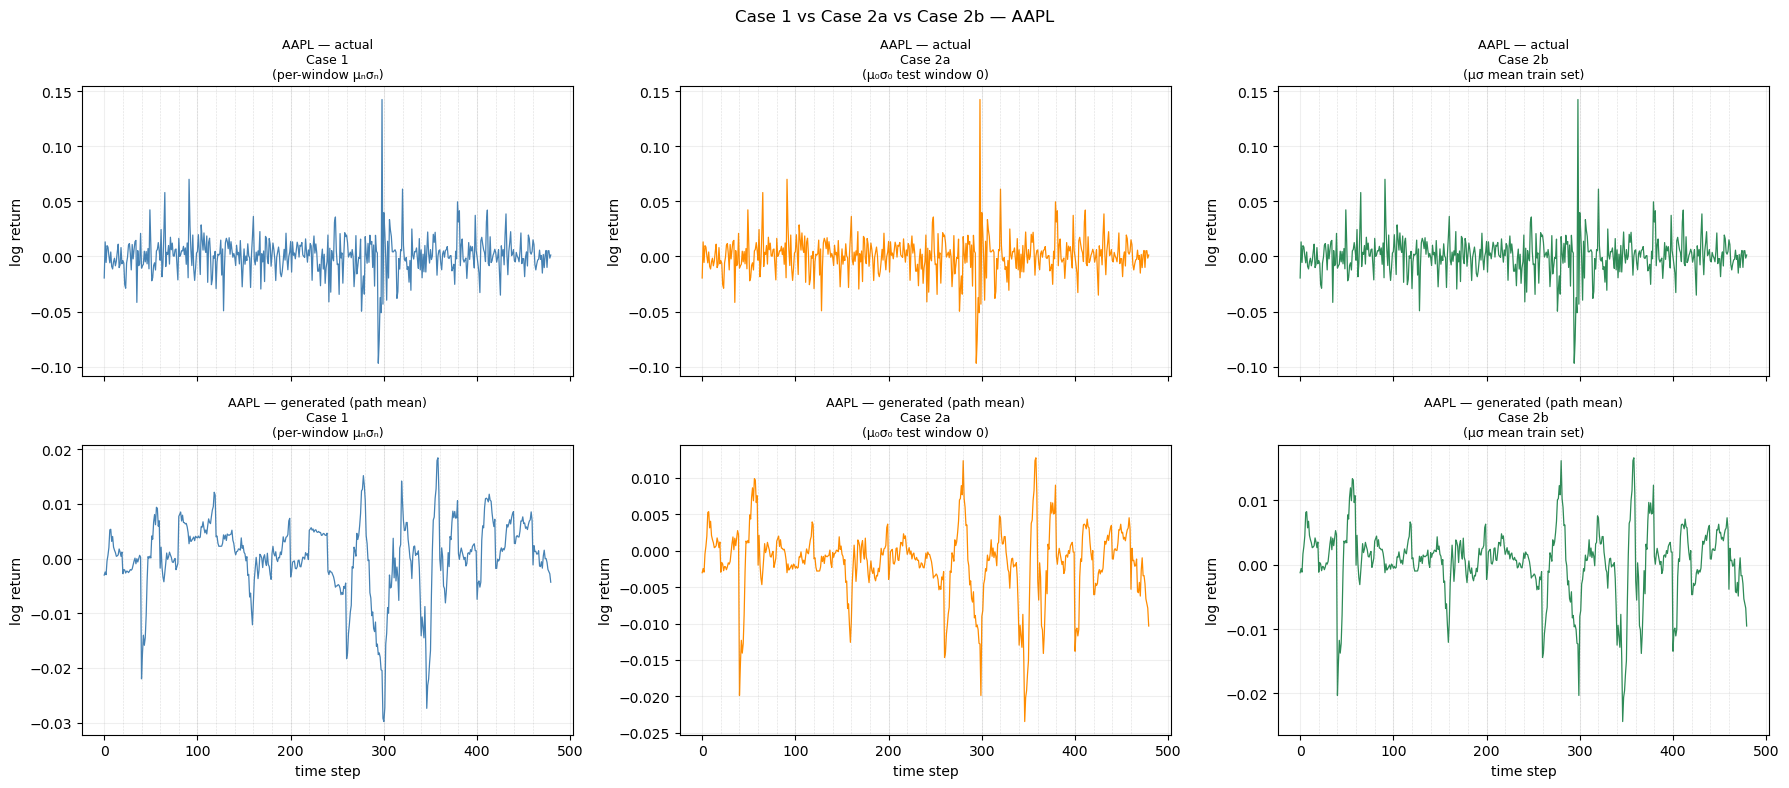

In [ ]:
# ── Plot 2×3: actual (top) + generated (bottom), 3 cases (columns) ─────────
asset_idx = 0
sym0 = symbols[asset_idx]
N_w, P_w, A_w, T_w, C_w = generated_renorm.shape
t    = np.arange(actual_cat.shape[1])

cases = [
    ('Case 1\n(per-window μₙσₙ)',    actual_cat[asset_idx],  gen_cat[:, asset_idx, :].mean(0),    'steelblue'),
    ('Case 2a\n(μ₀σ₀ test window 0)', act_cat_2a[asset_idx], gen_cat_2a[:, asset_idx, :].mean(0), 'darkorange'),
    ('Case 2b\n(μσ mean train set)',   act_cat_2b[asset_idx], gen_cat_2b[:, asset_idx, :].mean(0), 'seagreen'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for col, (title, act, gen_mean, color) in enumerate(cases):
    for row, (series, row_lbl) in enumerate([(act, 'actual'), (gen_mean, 'generated (path mean)')]):
        ax = axes[row, col]
        ax.plot(t, series, lw=0.9, color=color)
        for w in range(1, N_w):
            ax.axvline(w * T_w, color='gray', lw=0.4, linestyle=':', alpha=0.5)
        ax.set_title(f'{sym0} — {row_lbl}\n{title}', fontsize=9)
        ax.set_ylabel('log return')
        ax.grid(alpha=0.2)
    axes[1, col].set_xlabel('time step')

fig.suptitle(f'Case 1 vs Case 2a vs Case 2b — {sym0}', fontsize=12)
plt.tight_layout()
plt.show()



════════════════════════════════════════════════════════════
  Case 1 — per-window μₙσₙ
════════════════════════════════════════════════════════════
  📈 forecast plots...
  AAPL  →  forecast_logret_AAPL.png  |  forecast_price_AAPL.png
  TSLA  →  forecast_logret_TSLA.png  |  forecast_price_TSLA.png
  MSFT  →  forecast_logret_MSFT.png  |  forecast_price_MSFT.png
  NVDA  →  forecast_logret_NVDA.png  |  forecast_price_NVDA.png
  GOOGL  →  forecast_logret_GOOGL.png  |  forecast_price_GOOGL.png
  AMZN  →  forecast_logret_AMZN.png  |  forecast_price_AMZN.png
  GOOG  →  forecast_logret_GOOG.png  |  forecast_price_GOOG.png
  META  →  forecast_logret_META.png  |  forecast_price_META.png
  AVGO  →  forecast_logret_AVGO.png  |  forecast_price_AVGO.png
  ORCL  →  forecast_logret_ORCL.png  |  forecast_price_ORCL.png
  CRM  →  forecast_logret_CRM.png  |  forecast_price_CRM.png
  ADBE  →  forecast_logret_ADBE.png  |  forecast_price_ADBE.png
  AMD  →  forecast_logret_AMD.png  |  forecast_price_AMD.png

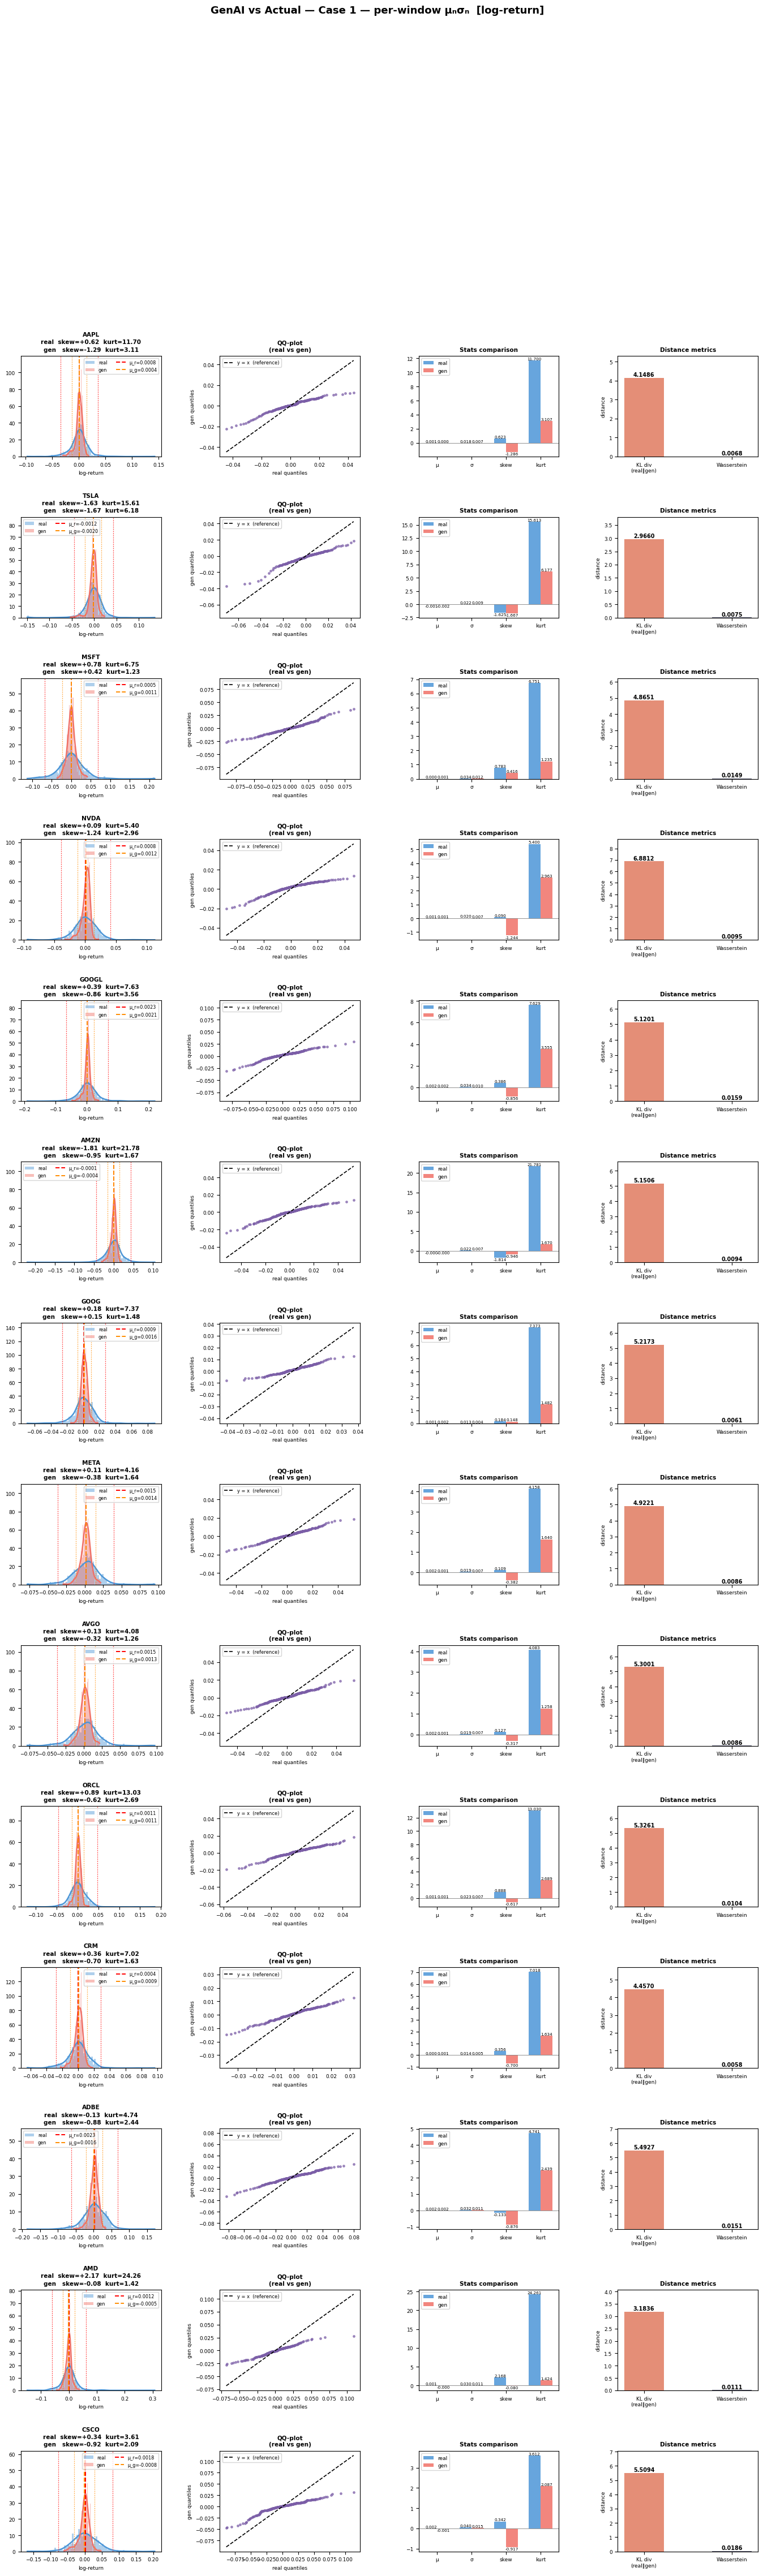

  🔗 correlation plots...


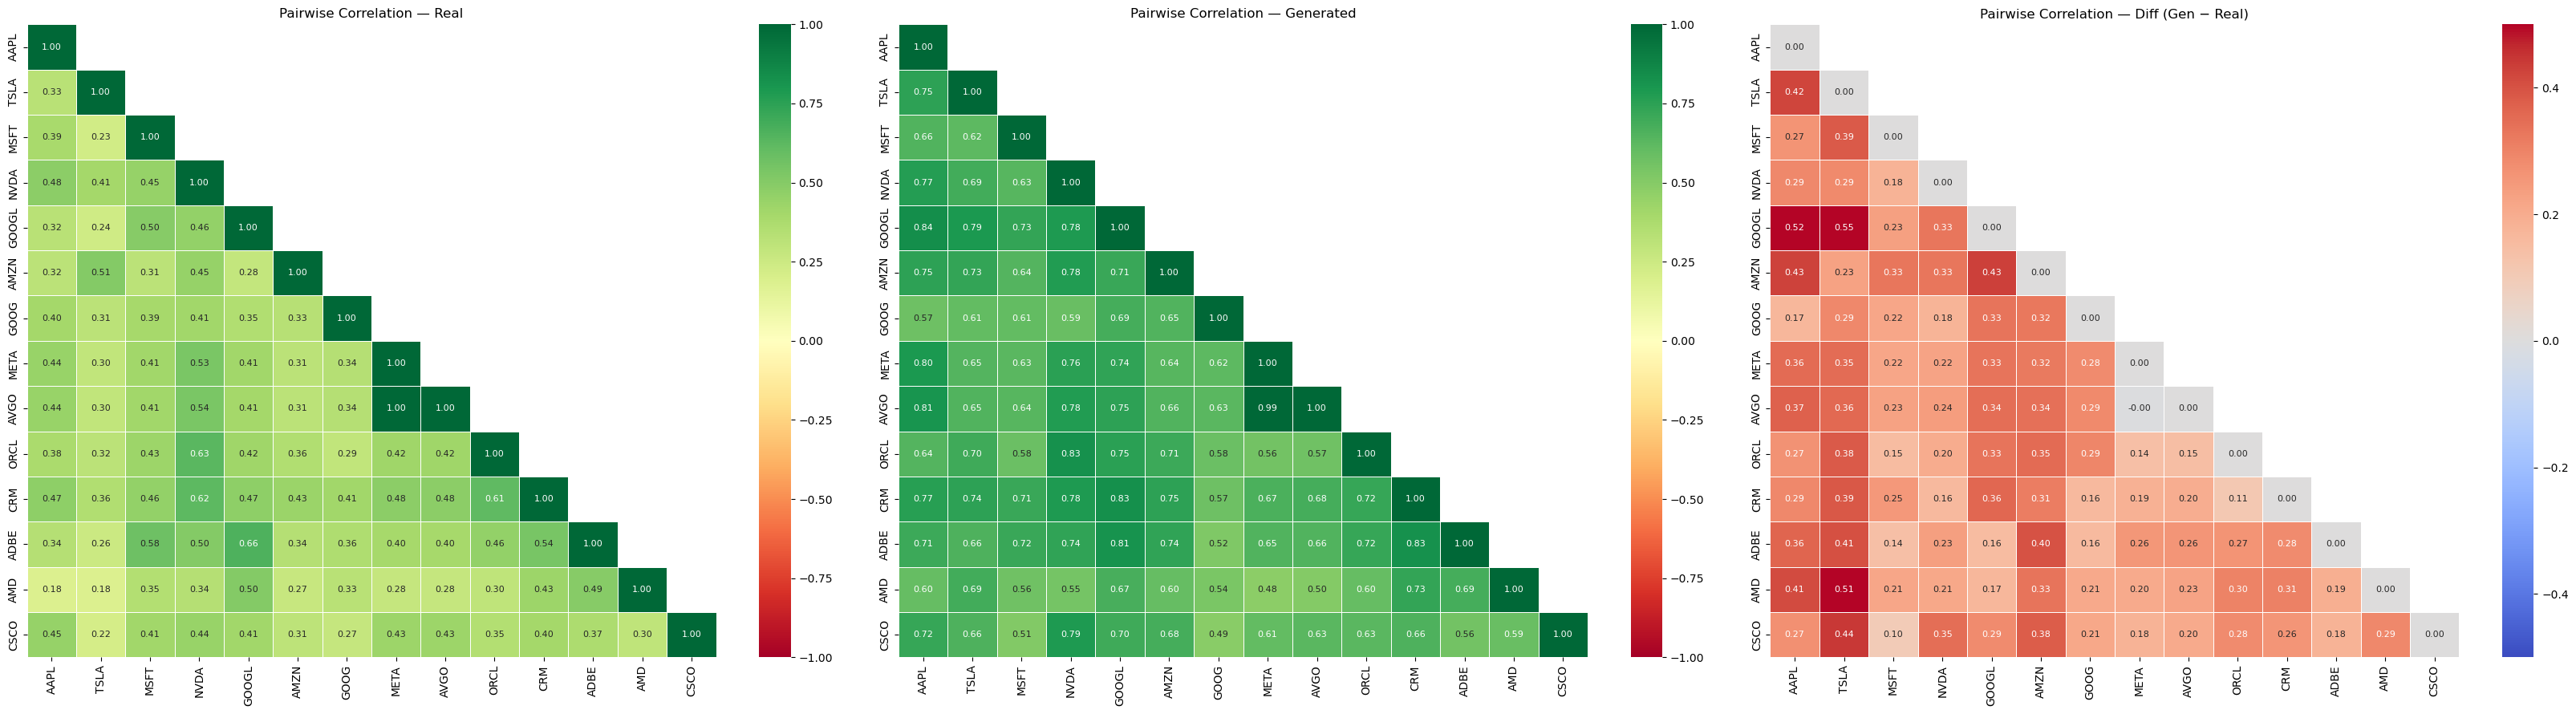


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.994,-0.004


  📉 rolling vol plots...


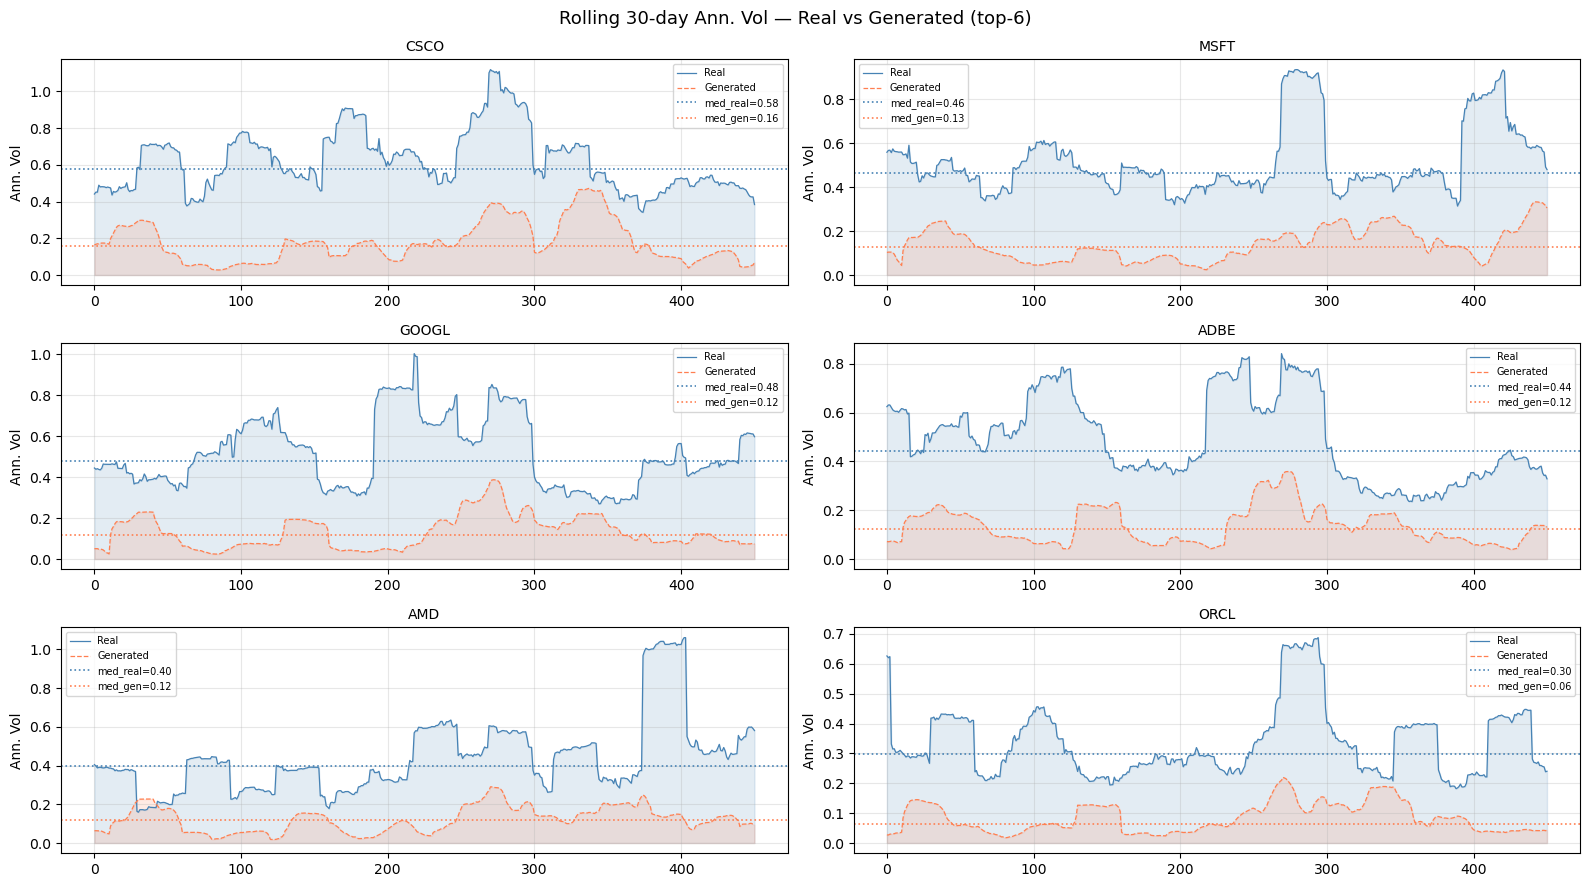

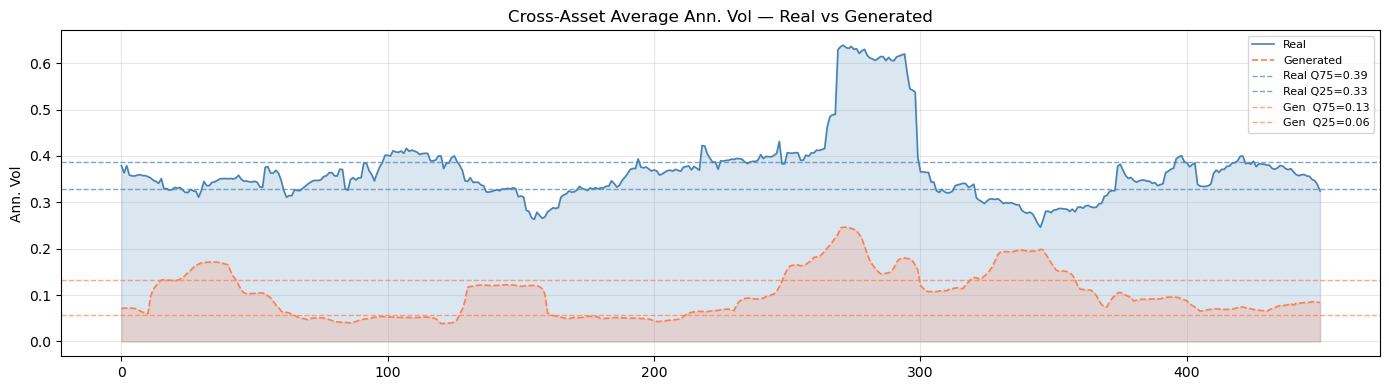


  Metrics (z-score normalized — shape/pattern comparison):
          MSE_z     MAE_z      KL_z  Wasserstein_z      R2_z
asset                                                       
AAPL   1.940102  0.971907  0.776464       0.156665 -0.940105
TSLA   1.919001  0.947334  0.893710       0.101116 -0.919003
MSFT   1.971698  1.043355  1.832489       0.103104 -0.971699
NVDA   1.889527  1.043954  1.180427       0.192494 -0.889529
GOOGL  1.976294  0.999096  1.046592       0.134965 -0.976296
AMZN   1.976217  1.032857  0.804635       0.178235 -0.976218
GOOG   1.983920  1.082438  1.071229       0.128749 -0.983923
META   1.975438  1.052948  0.931697       0.069962 -0.975440
AVGO   1.954883  1.057602  1.221196       0.077763 -0.954883
ORCL   2.010587  1.034649  0.493425       0.133092 -1.010590
CRM    1.949662  1.049117  0.974225       0.095224 -0.949665
ADBE   1.901900  1.037718  0.780296       0.085862 -0.901900
AMD    1.987159  0.990734  0.539611       0.173013 -0.987160
CSCO   1.991405  1.031177

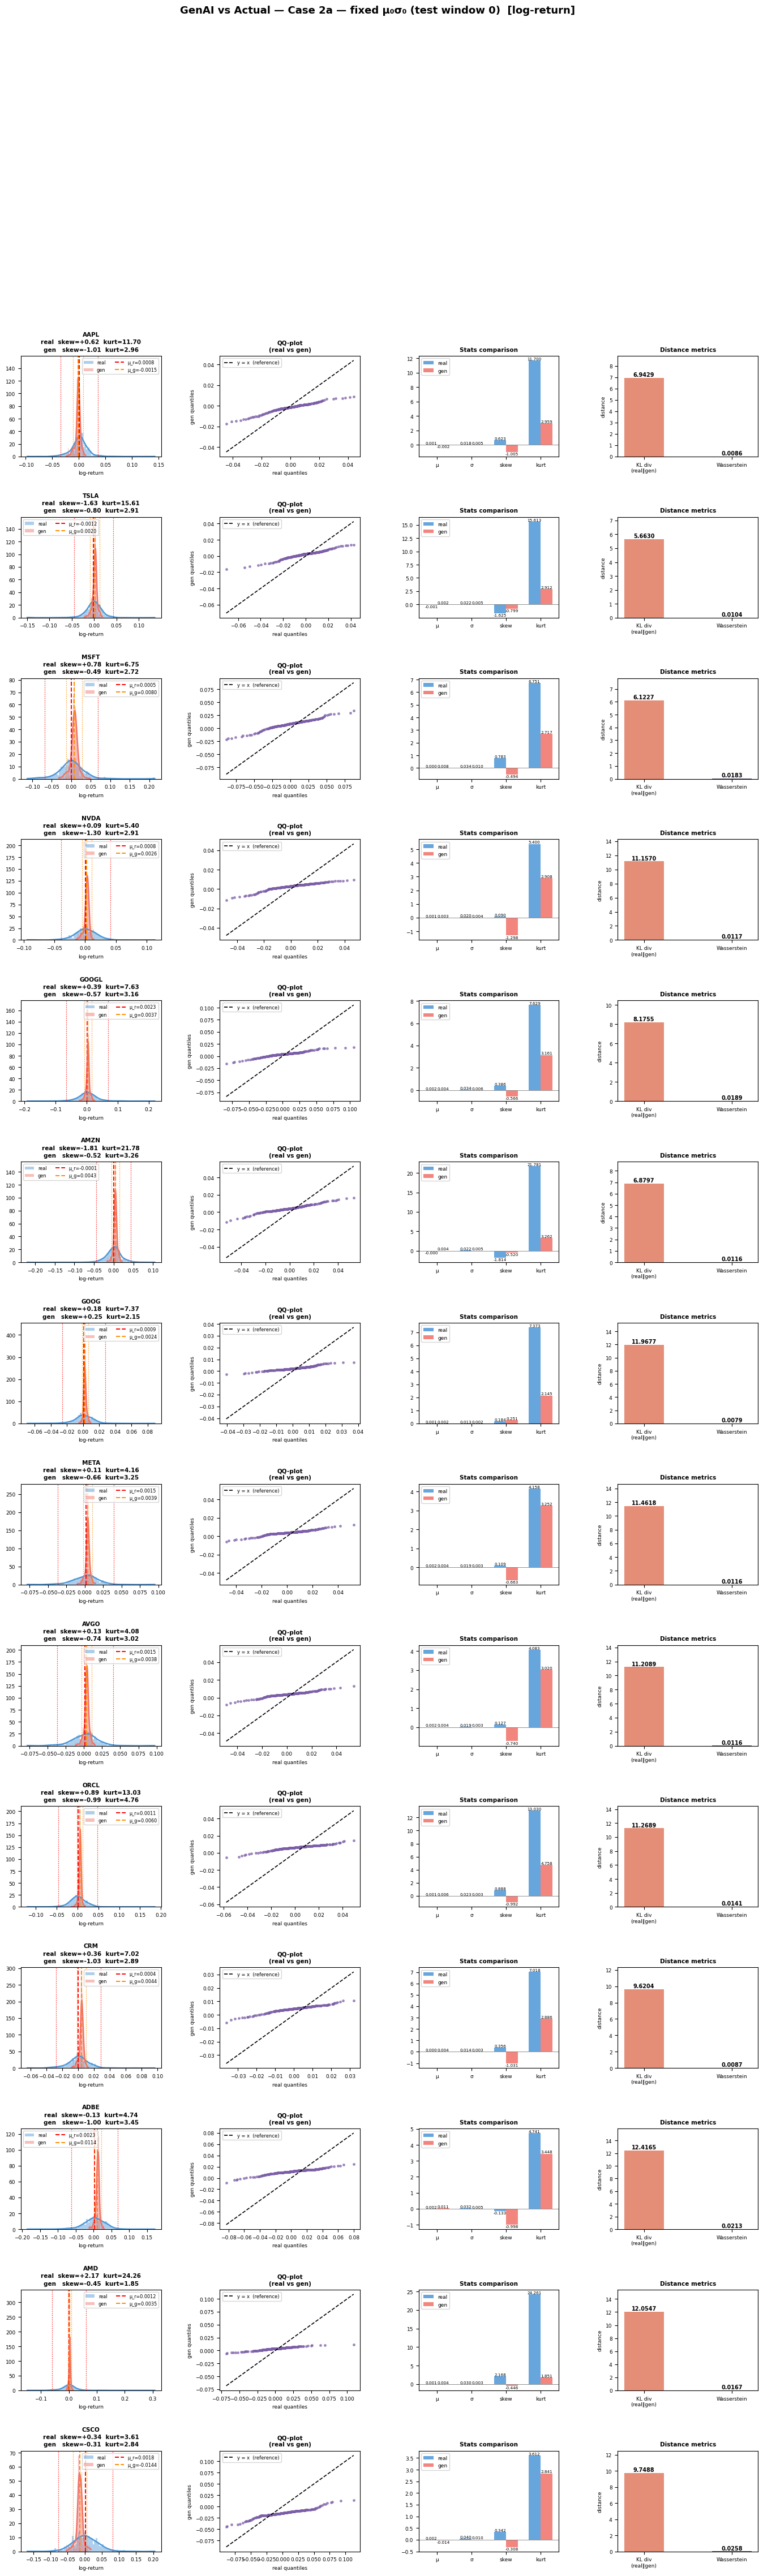

  🔗 correlation plots...


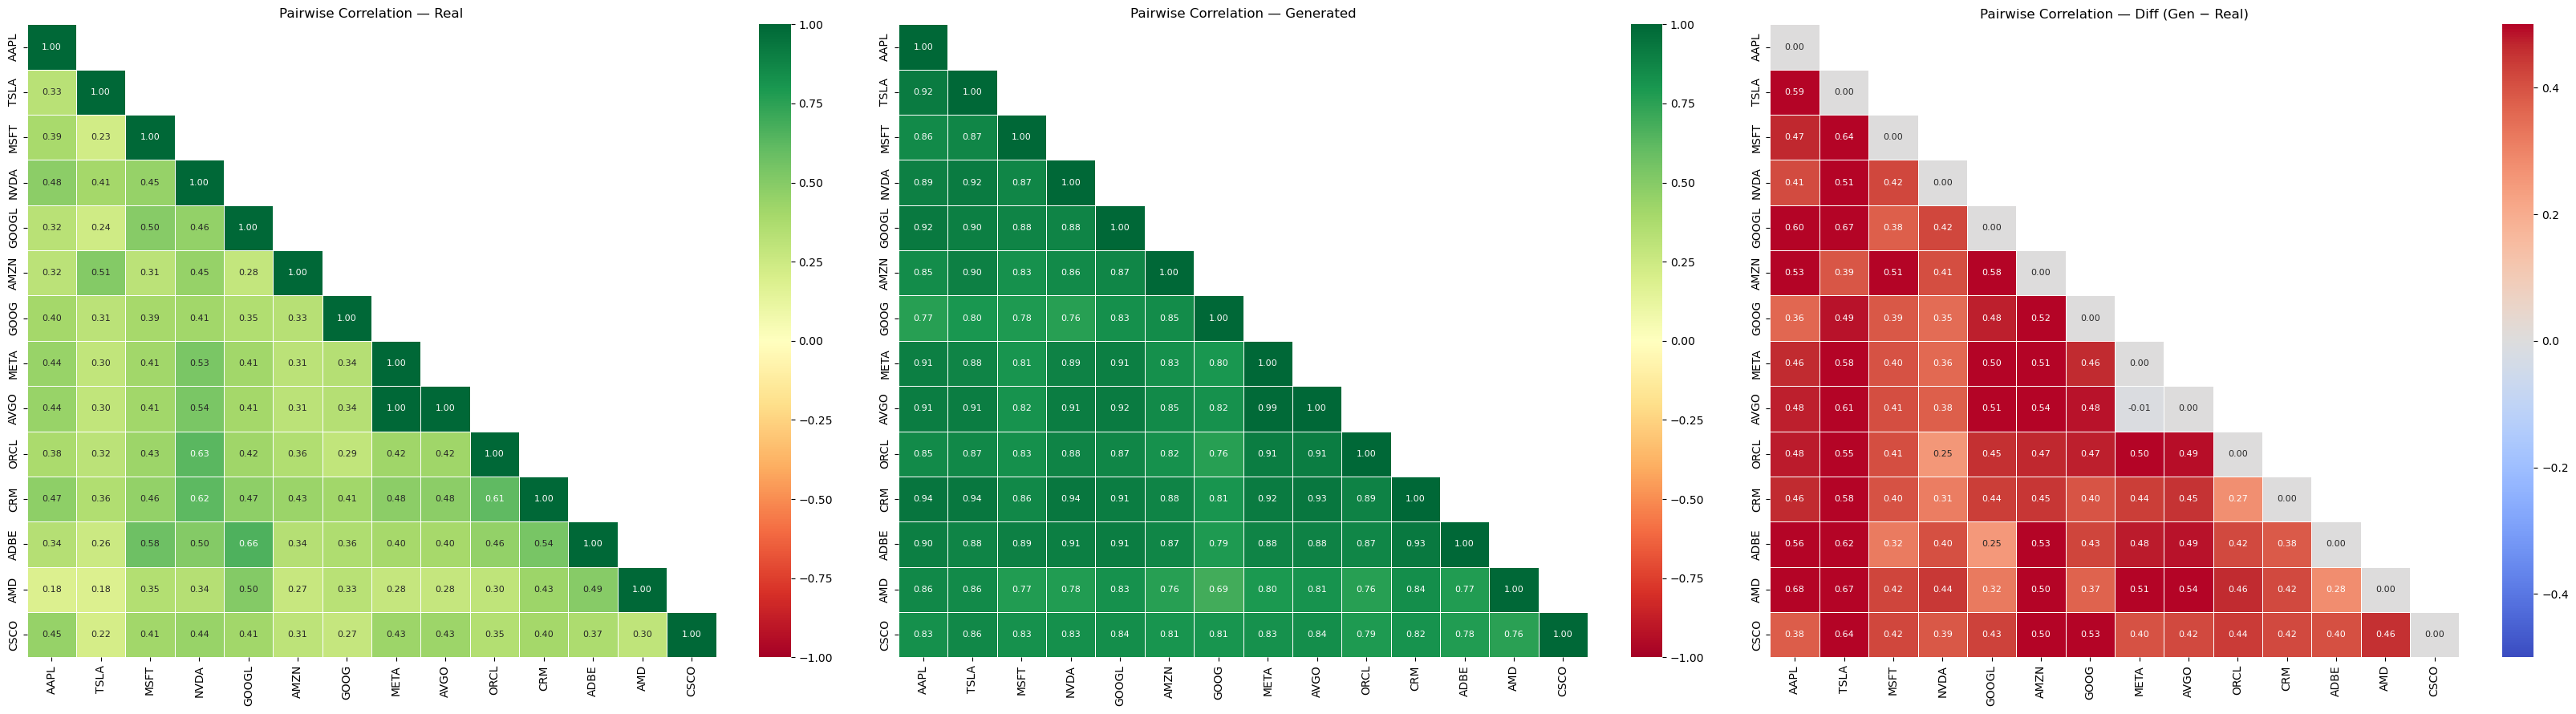


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.989,-0.009
1,GOOGL,ADBE,0.658,0.908,0.250
2,NVDA,ORCL,0.626,0.881,0.255
3,NVDA,CRM,0.623,0.937,0.314
4,ORCL,CRM,0.613,0.887,0.274
5,MSFT,ADBE,0.576,0.893,0.317
6,CRM,ADBE,0.543,0.927,0.384
7,NVDA,AVGO,0.537,0.913,0.376
8,NVDA,META,0.533,0.889,0.356
9,TSLA,AMZN,0.506,0.897,0.391


  📉 rolling vol plots...


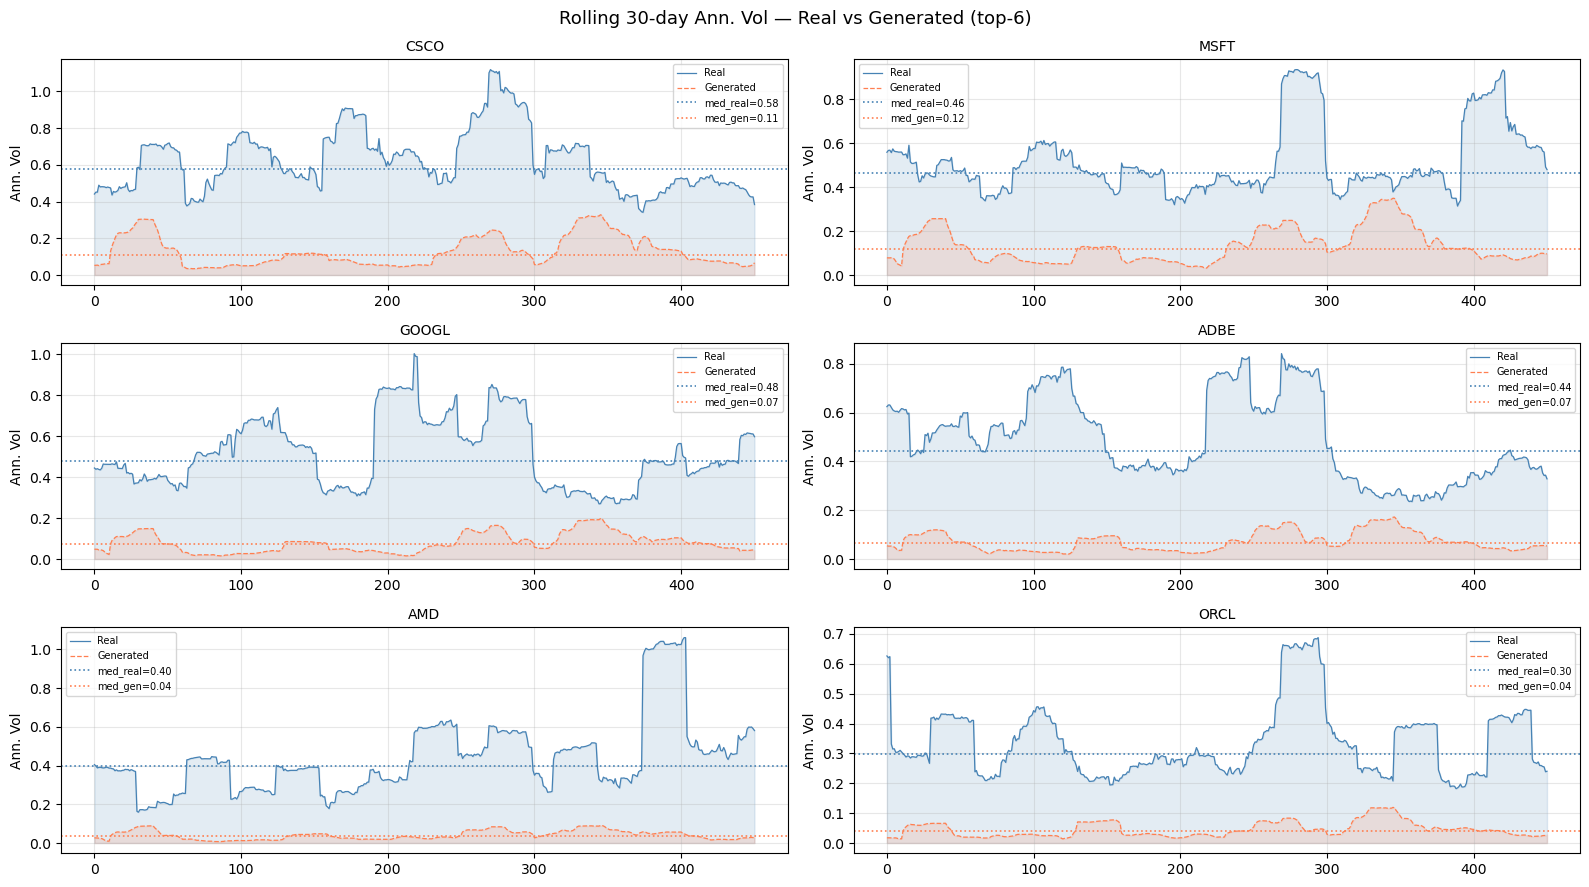

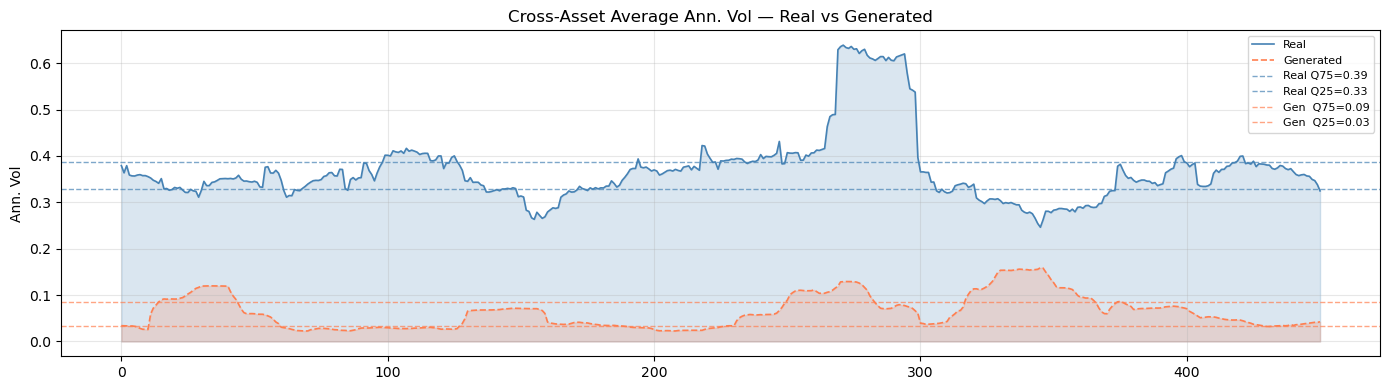


  Metrics (z-score normalized — shape/pattern comparison):
          MSE_z     MAE_z      KL_z  Wasserstein_z      R2_z
asset                                                       
AAPL   1.939497  0.980383  0.822860       0.137735 -0.939500
TSLA   1.921791  0.949935  1.007867       0.127887 -0.921793
MSFT   1.960931  1.014992  1.518500       0.112696 -0.960932
NVDA   1.897789  1.043811  1.671633       0.193689 -0.897792
GOOGL  2.012816  1.017130  1.041626       0.126640 -1.012818
AMZN   1.960244  1.008725  0.765338       0.097303 -0.960245
GOOG   1.979630  1.044523  0.779447       0.135203 -0.979633
META   2.013579  1.047660  2.358742       0.126510 -1.013581
AVGO   1.980866  1.049594  1.430476       0.117123 -0.980866
ORCL   1.995757  1.014231  0.828522       0.147182 -0.995760
CRM    1.958373  1.011068  1.116801       0.131148 -0.958376
ADBE   1.925216  1.032667  1.312719       0.137258 -0.925216
AMD    2.044153  0.982844  0.888061       0.172881 -1.044153
CSCO   2.038616  1.052625

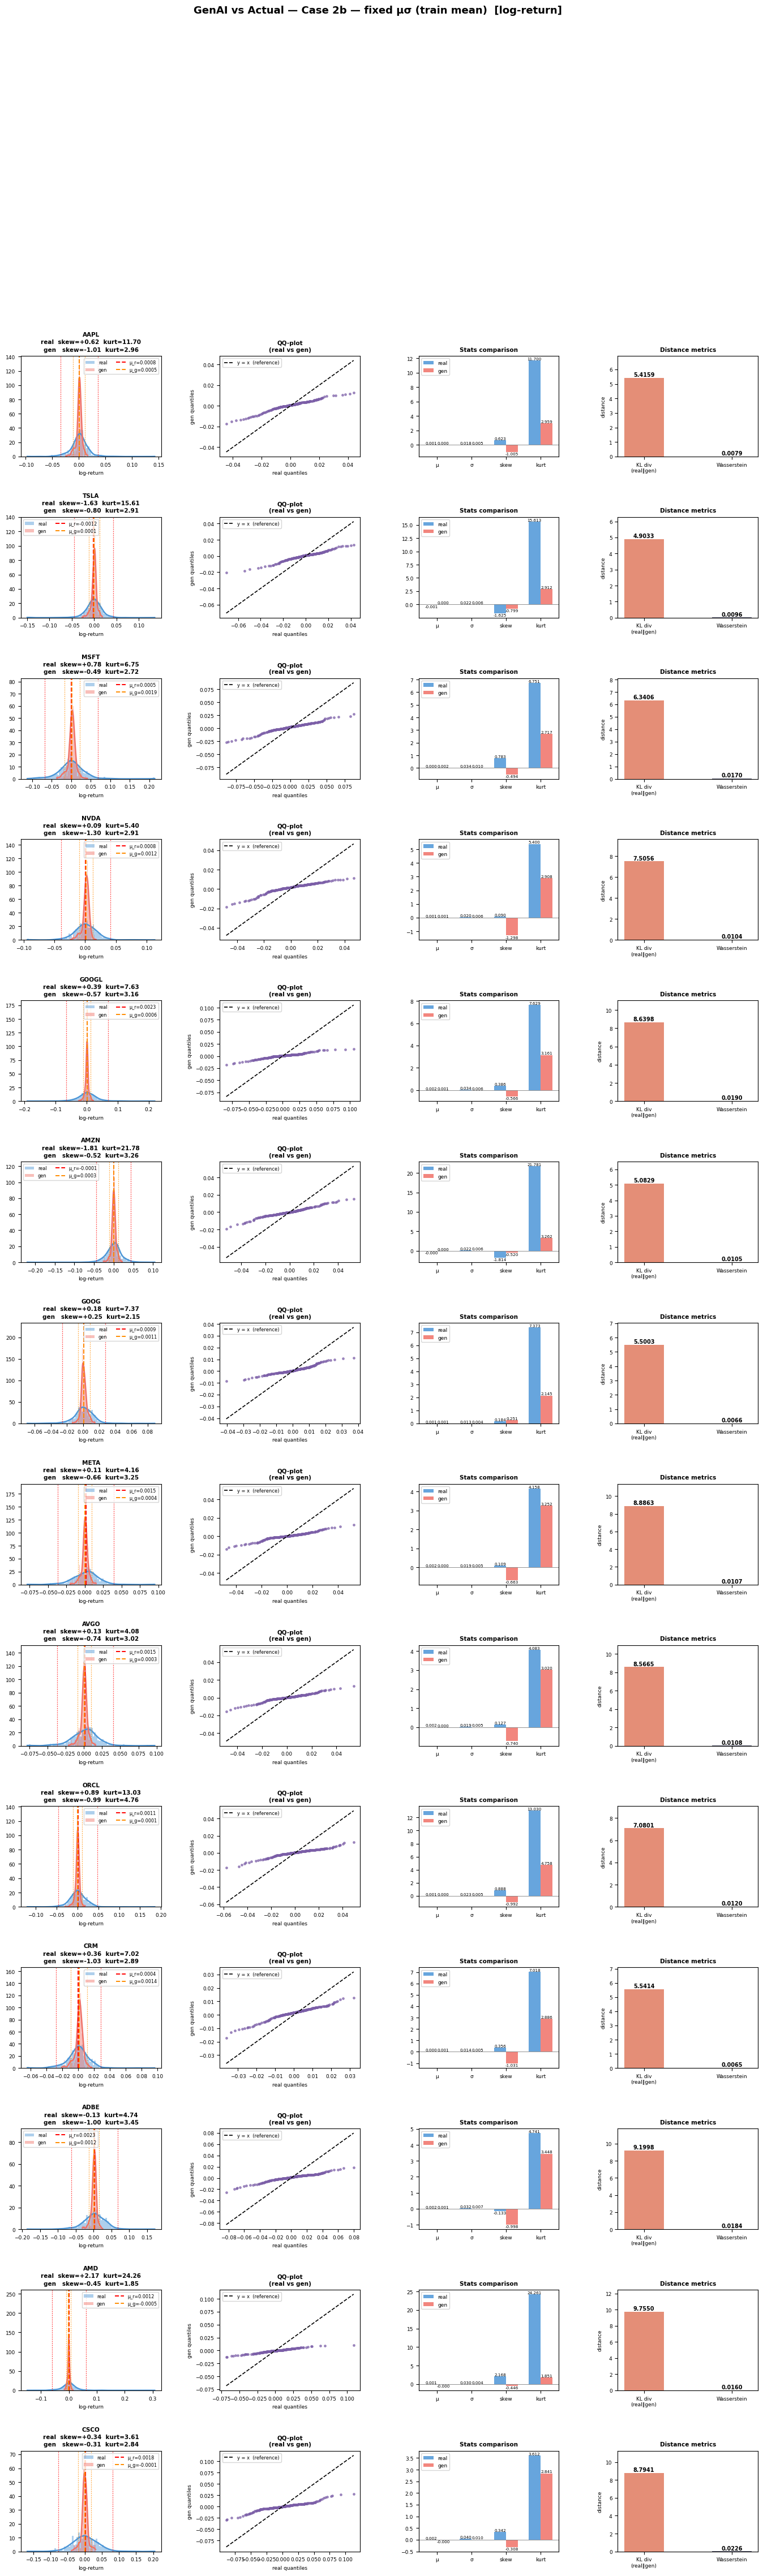

  🔗 correlation plots...


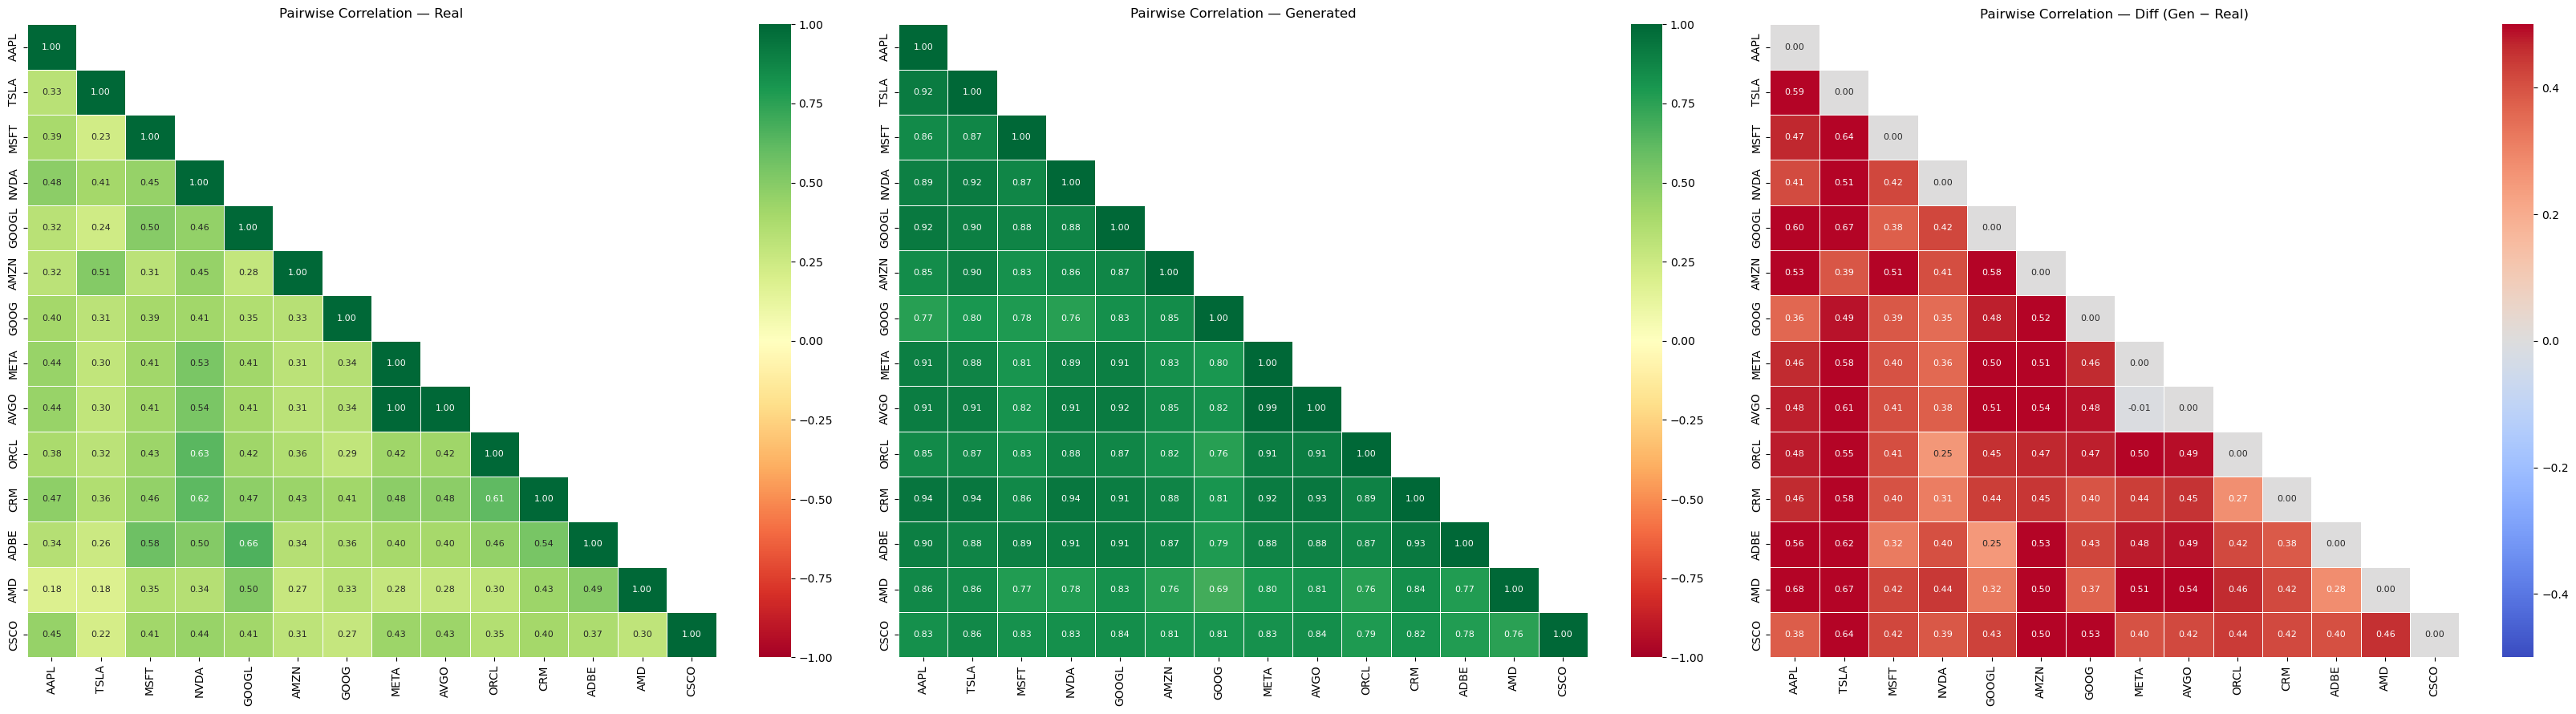


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.989,-0.009
1,GOOGL,ADBE,0.658,0.908,0.250
2,NVDA,ORCL,0.626,0.881,0.255
3,NVDA,CRM,0.623,0.937,0.314
4,ORCL,CRM,0.613,0.887,0.274
5,MSFT,ADBE,0.576,0.893,0.317
6,CRM,ADBE,0.543,0.927,0.384
7,NVDA,AVGO,0.537,0.913,0.376
8,NVDA,META,0.533,0.889,0.356
9,TSLA,AMZN,0.506,0.897,0.391


  📉 rolling vol plots...


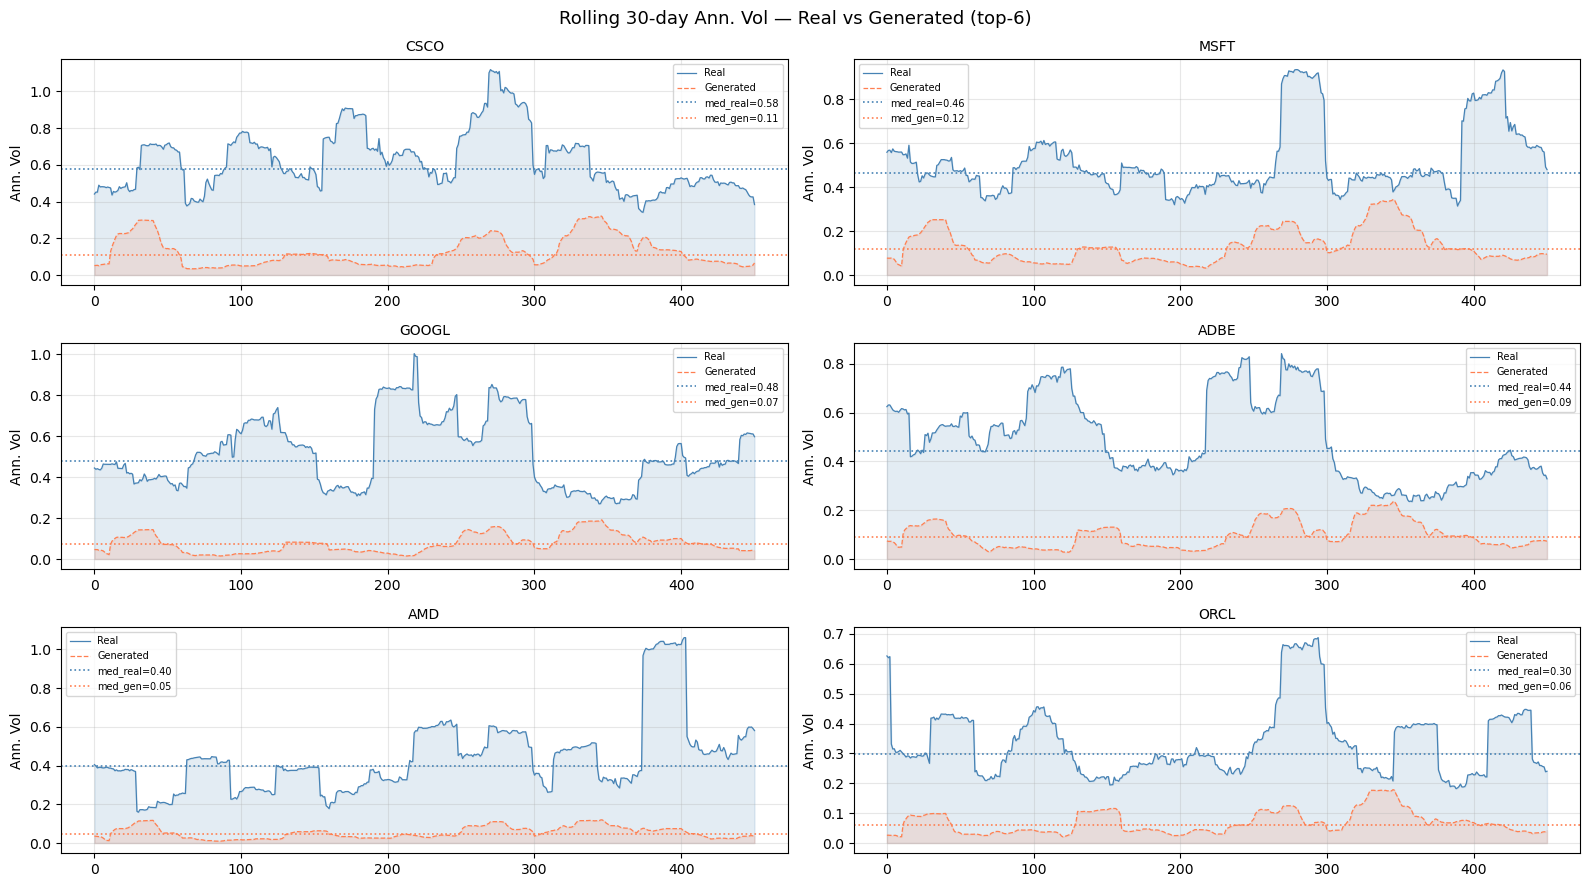

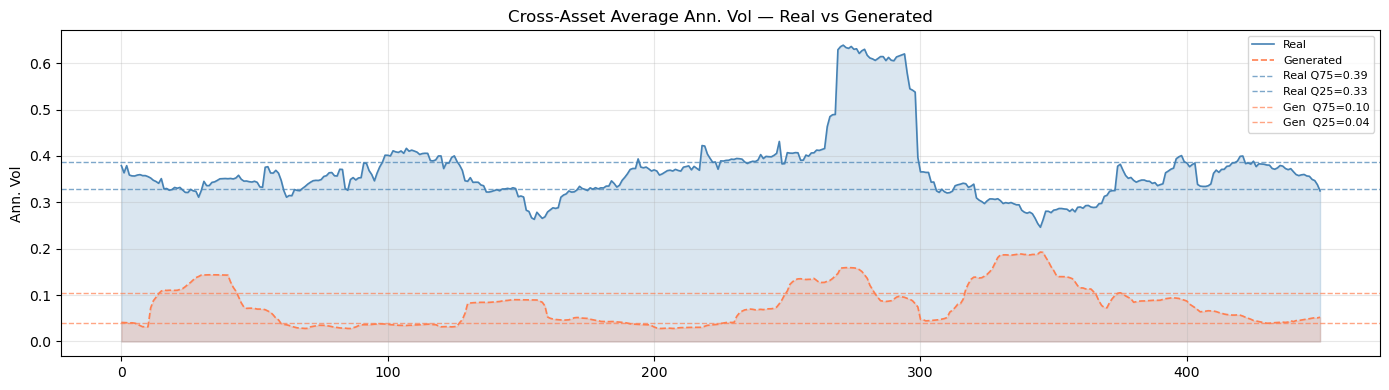


  Metrics (z-score normalized — shape/pattern comparison):
          MSE_z     MAE_z      KL_z  Wasserstein_z      R2_z
asset                                                       
AAPL   1.939498  0.980383  0.822860       0.137735 -0.939500
TSLA   1.921792  0.949935  1.007867       0.127887 -0.921793
MSFT   1.960931  1.014992  1.518500       0.112696 -0.960931
NVDA   1.897791  1.043811  1.671633       0.193689 -0.897794
GOOGL  2.012815  1.017130  1.041626       0.126640 -1.012818
AMZN   1.960244  1.008725  0.765338       0.097303 -0.960246
GOOG   1.979635  1.044524  0.779447       0.135203 -0.979639
META   2.013581  1.047661  2.358742       0.126510 -1.013583
AVGO   1.980868  1.049595  1.430476       0.117123 -0.980868
ORCL   1.995759  1.014232  0.828522       0.147182 -0.995762
CRM    1.958376  1.011069  1.116801       0.131149 -0.958379
ADBE   1.925217  1.032667  1.312719       0.137258 -0.925217
AMD    2.044155  0.982845  0.888061       0.172882 -1.044155
CSCO   2.038616  1.052625

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 29 — Directory setup & bundle all 3 cases
# ════════════════════════════════════════════════════════════════════════════

# ── Case bundles ─────────────────────────────────────────────────────────────
# actual_cat  [A, H]         — Case 1 (per-window, ground truth scale)
# gen_cat     [P, A, H]      — Case 1
# gen_cat_2a  [P, A, H]      — Case 2a (fixed σ₀ from test window 0)
# gen_cat_2b  [P, A, H]      — Case 2b (fixed σ from train mean)
# act_cat_2a / act_cat_2b    — actual re-scaled (same fixed σ) for reference

cases_bundle = {
    "case1_per_window": {
        "gen"   : gen_cat,
        "act"   : actual_cat,       # [A, H]
        "label" : "Case 1 — per-window μₙσₙ",
        "color" : "steelblue",
    },
    "case2a_fixed_test0": {
        "gen"   : gen_cat_2a,
        "act"   : actual_cat,       # ← actual ใช้ Case 1 เสมอ (scale จริง)
        "label" : "Case 2a — fixed μ₀σ₀ (test window 0)",
        "color" : "darkorange",
    },
    "case2b_train_mean": {
        "gen"   : gen_cat_2b,
        "act"   : actual_cat,       # ← actual ใช้ Case 1 เสมอ
        "label" : "Case 2b — fixed μσ (train mean)",
        "color" : "seagreen",
    },
}

# ── Folder structure ──────────────────────────────────────────────────────────
# sim_dir/
# ├── norm_case1_per_window/
# │   ├── plots/forecast/   forecast_logret_*.png, forecast_price_*.png
# │   ├── plots/dist_*.png, corr_*.png, vol_*.png
# │   └── reports/metrics_*.csv
# ├── norm_case2a_fixed_test0/  (same structure)
# └── norm_case2b_train_mean/   (same structure)

for case_key, bundle in cases_bundle.items():
    case_dir     = sim_dir / f"norm_{case_key}"
    plots_dir_c  = case_dir / "plots"
    reports_dir_c= case_dir / "reports"
    fc_dir       = plots_dir_c / "forecast"
    for d in [plots_dir_c, reports_dir_c, fc_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n{'═'*60}")
    print(f"  {bundle['label']}")
    print(f"{'═'*60}")

    gen_c = bundle["gen"]    # [P, A, H]
    act_c = bundle["act"]    # [A, H]

    # ── [T, A] prep ──────────────────────────────────────────────────────────
    act_TA = act_c.T                    # [H, A]
    gen_TA = gen_c.mean(axis=0).T      # [H, A]

    # ── 1. plot_forecast_all_assets ──────────────────────────────────────────
    print(f"  📈 forecast plots...")
    plot_forecast_all_assets(
        gen_cat         = gen_c,
        actual_cat      = act_c,
        gbm_paths       = gbm_paths,   # GBM เหมือนกันทุก case (scale ตาม Case 1)
        close_prices    = close_prices,
        symbols         = symbols,
        plots_dir       = fc_dir,
        alpha_paths     = 0.08,
        n_paths_display = None,
    )

    # ── 2. Distribution comparison ────────────────────────────────────────────
    print(f"  📊 distribution plots...")
    fig, _ = plot_compare_dist(act_TA, gen_TA, symbols,
                               title=f"GenAI vs Actual — {bundle['label']}")
    fig.savefig(plots_dir_c / "dist_genai_vs_actual.png", bbox_inches="tight", dpi=120)
    plt.close(fig)

    # ── 3. Correlation comparison ─────────────────────────────────────────────
    print(f"  🔗 correlation plots...")
    fig, _, _ = plot_compare_correlation(act_TA, gen_TA, symbols)
    fig.savefig(plots_dir_c / "corr_genai_vs_actual.png", bbox_inches="tight", dpi=120)
    plt.close(fig)

    # ── 4. Rolling vol comparison ─────────────────────────────────────────────
    print(f"  📉 rolling vol plots...")
    fig1, fig2 = plot_compare_rolling_vol(act_TA, gen_TA, symbols)
    fig1.savefig(plots_dir_c / "vol_genai_vs_actual_per_asset.png", bbox_inches="tight", dpi=120)
    fig2.savefig(plots_dir_c / "vol_genai_vs_actual_avg.png",       bbox_inches="tight", dpi=120)
    plt.close(fig1); plt.close(fig2)

    # ── 5. Metrics ────────────────────────────────────────────────────────────
    # ใช้ z-score normalized series เพื่อให้ metric ยุติธรรมข้าม case
    # (scale ต่างกัน → MSE/MAE ไม่ comparable โดยตรง แต่ KL/Wasserstein ยังโอเค)
    def _zscore(arr):
        """arr : [T, A] → z-scored per column"""
        mu  = arr.mean(axis=0, keepdims=True)
        sig = arr.std(axis=0,  keepdims=True) + 1e-8
        return (arr - mu) / sig

    act_z = _zscore(act_TA)
    gen_z = _zscore(gen_TA)

    rows_raw, rows_z = [], []
    for i, sym in enumerate(symbols):
        r   = act_TA[:, i].astype(float)
        g   = gen_TA[:, i].astype(float)
        rz  = act_z[:, i].astype(float)
        gz  = gen_z[:, i].astype(float)
        n   = min(len(r), len(g))

        # raw metrics
        rows_raw.append({
            "asset"        : sym,
            "MSE"          : round(float(np.mean((r[:n] - g[:n])**2)), 8),
            "MAE"          : round(float(np.mean(np.abs(r[:n] - g[:n]))), 8),
            "KL"           : round(_kl_divergence(r, g), 6),
            "Wasserstein"  : round(float(wasserstein_distance(r, g)), 6),
            "R2"           : round(float(r2_score(r[:n], g[:n])), 6),
        })
        # z-score normalized metrics (shape/pattern agnostic of scale)
        rows_z.append({
            "asset"        : sym,
            "MSE_z"        : round(float(np.mean((rz[:n] - gz[:n])**2)), 6),
            "MAE_z"        : round(float(np.mean(np.abs(rz[:n] - gz[:n]))), 6),
            "KL_z"         : round(_kl_divergence(rz, gz), 6),
            "Wasserstein_z": round(float(wasserstein_distance(rz, gz)), 6),
            "R2_z"         : round(float(r2_score(rz[:n], gz[:n])), 6),
        })

    df_raw = pd.DataFrame(rows_raw).set_index("asset")
    df_z   = pd.DataFrame(rows_z).set_index("asset")
    df_raw.to_csv(reports_dir_c / "metrics_raw.csv")
    df_z.to_csv(reports_dir_c   / "metrics_normalized.csv")

    print(f"\n  Metrics (z-score normalized — shape/pattern comparison):")
    print(df_z.to_string())
    print(f"\n  ✅ Saved → {case_dir}")

print(f"\n\n{'═'*60}")
print(f"  ✅ All 3 cases done!")
print(f"  {sim_dir}/")
print(f"  ├── norm_case1_per_window/")
print(f"  ├── norm_case2a_fixed_test0/")
print(f"  └── norm_case2b_train_mean/")
print(f"      ├── plots/")
print(f"      │   ├── forecast/  (logret + price per asset)")
print(f"      │   ├── dist_genai_vs_actual.png")
print(f"      │   ├── corr_genai_vs_actual.png")
print(f"      │   └── vol_genai_vs_actual_*.png")
print(f"      └── reports/")
print(f"          ├── metrics_raw.csv         (absolute scale)")
print(f"          └── metrics_normalized.csv  (z-score, fair cross-case)")
print(f"{'═'*60}")


# ════════════════════════════════════════════════════════════════════════════
# Cell 30 — Cross-case summary: metrics_normalized เปรียบเทียบทั้ง 3 case
# ════════════════════════════════════════════════════════════════════════════

summary_rows = {}
for case_key, bundle in cases_bundle.items():
    csv_path = sim_dir / f"norm_{case_key}" / "reports" / "metrics_normalized.csv"
    df_tmp   = pd.read_csv(csv_path, index_col="asset")
    for col in df_tmp.columns:
        summary_rows[f"{case_key}__{col}"] = df_tmp[col]

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(sim_dir / "cross_case_metrics_summary.csv")

# ── Pretty pivot: per metric, 3 cases as columns ──────────────────────────
print("\nCross-case summary (z-score normalized metrics):\n")
for metric in ["MSE_z", "MAE_z", "KL_z", "Wasserstein_z", "R2_z"]:
    cols = [c for c in df_summary.columns if c.endswith(metric)]
    df_m = df_summary[cols].copy()
    df_m.columns = [c.replace(f"__{metric}", "").replace("norm_", "") for c in cols]
    print(f"── {metric} ──")
    print(df_m.round(4).to_string())
    print()

print(f"✅ Cross-case summary saved → {sim_dir / 'cross_case_metrics_summary.csv'}")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 31 — Side-by-side comparison plots: Case 1 vs 2a vs 2b
#
# บันทึกลง sim_dir/plots/case_comparison/
#   1. compare_generated_<sym>.png  — generated fan ทั้ง 3 case ซ้อนกัน
#   2. compare_actual_vs_gen_<sym>.png — actual vs gen mean ทั้ง 3 case
#   3. compare_std_bar.png          — std ของ generated แต่ละ case ทุก asset
#   4. compare_metrics_heatmap.png  — heatmap metrics (z-score) ทั้ง 3 case
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

cmp_dir = sim_dir / "plots" / "case_comparison"
cmp_dir.mkdir(parents=True, exist_ok=True)

CASE_STYLES = {
    "case1_per_window"     : {"label": "Case 1 — per-window μₙσₙ",          "color": "#4C96D7", "ls": "-"},
    "case2a_fixed_test0"   : {"label": "Case 2a — fixed μ₀σ₀ (test win 0)", "color": "#F07167", "ls": "--"},
    "case2b_train_mean"    : {"label": "Case 2b — fixed μσ (train mean)",    "color": "#43AA8B", "ls": "-."},
}

gen_by_case = {
    "case1_per_window"   : gen_cat,
    "case2a_fixed_test0" : gen_cat_2a,
    "case2b_train_mean"  : gen_cat_2b,
}
# actual scale เดิมเสมอ (Case 1)
act = actual_cat   # [A, H]
t   = np.arange(act.shape[1])

# ─────────────────────────────────────────────────────────────────────────────
# Plot 1: compare_generated_<sym>.png
#   แสดง generated path mean + 10-90% band ทั้ง 3 case ซ้อนกัน + actual
# ─────────────────────────────────────────────────────────────────────────────
print("📈 Plot 1: generated fan comparison per asset...")
for a_idx, sym in enumerate(symbols):
    fig, ax = plt.subplots(figsize=(14, 5))

    # actual (ground truth)
    ax.plot(t, act[a_idx], color="black", lw=1.8, zorder=10,
            label="Actual (ground truth)", alpha=0.85)

    for case_key, style in CASE_STYLES.items():
        gen_c   = gen_by_case[case_key]          # [P, A, H]
        gen_a   = gen_c[:, a_idx, :]              # [P, H]
        g_mean  = gen_a.mean(axis=0)
        g_p10, g_p90 = np.percentile(gen_a, [10, 90], axis=0)

        ax.fill_between(t, g_p10, g_p90,
                        color=style["color"], alpha=0.12)
        ax.plot(t, g_mean, color=style["color"], lw=1.8,
                ls=style["ls"], label=style["label"], zorder=5)

    # window boundaries
    N_w = generated_renorm.shape[0]
    T_w = generated_renorm.shape[3]
    for w in range(1, N_w):
        ax.axvline(w * T_w, color="gray", lw=0.4, ls=":", alpha=0.4)

    ax.set_title(f"{sym} — Generated (path mean ± 10–90%) across 3 Cases",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Log Return")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(cmp_dir / f"compare_generated_{sym}.png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    print(f"   {sym} ✓")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 2: compare_actual_vs_gen_<sym>.png
#   2 rows × 1 col:  top = actual,  bottom = gen mean ทั้ง 3 case overlay
# ─────────────────────────────────────────────────────────────────────────────
print("\n📈 Plot 2: actual vs generated mean (2-row) per asset...")
for a_idx, sym in enumerate(symbols):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={"hspace": 0.35})

    # Row 0: actual
    axes[0].plot(t, act[a_idx], color="black", lw=1.5)
    axes[0].set_title(f"{sym} — Actual (ground truth)", fontsize=11)
    axes[0].set_ylabel("Log Return")
    axes[0].grid(alpha=0.2)
    axes[0].spines[["top", "right"]].set_visible(False)

    # Row 1: generated mean all 3 cases
    for case_key, style in CASE_STYLES.items():
        gen_c  = gen_by_case[case_key][:, a_idx, :].mean(axis=0)
        axes[1].plot(t, gen_c, color=style["color"], lw=1.6,
                     ls=style["ls"], label=style["label"])

    axes[1].set_title(f"{sym} — Generated (path mean)", fontsize=11)
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("Log Return")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.2)
    axes[1].spines[["top", "right"]].set_visible(False)

    # window lines on both
    for ax in axes:
        for w in range(1, N_w):
            ax.axvline(w * T_w, color="gray", lw=0.4, ls=":", alpha=0.4)

    fig.suptitle(f"{sym} — Actual vs Generated: Case 1 / 2a / 2b",
                 fontsize=13, fontweight="bold")
    fig.savefig(cmp_dir / f"compare_actual_vs_gen_{sym}.png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    print(f"   {sym} ✓")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 3: compare_std_bar.png
#   bar chart: std ของ generated แต่ละ case ทุก asset
#   + actual std เป็น reference line
# ─────────────────────────────────────────────────────────────────────────────
print("\n📊 Plot 3: std bar chart across cases & assets...")
n_cases  = len(CASE_STYLES)
x        = np.arange(len(symbols))
width    = 0.22
offsets  = np.linspace(-(n_cases-1)/2, (n_cases-1)/2, n_cases) * width

fig, ax = plt.subplots(figsize=(max(12, len(symbols)*0.9), 5))

for i, (case_key, style) in enumerate(CASE_STYLES.items()):
    stds = [gen_by_case[case_key][:, a, :].std() for a in range(len(symbols))]
    ax.bar(x + offsets[i], stds, width,
           color=style["color"], alpha=0.82, label=style["label"])

# actual std as dots
act_stds = [act[a].std() for a in range(len(symbols))]
ax.scatter(x, act_stds, color="black", zorder=10, s=60,
           marker="D", label="Actual std")

ax.set_xticks(x)
ax.set_xticklabels(symbols, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Std of Log Return")
ax.set_title("Generated Std per Case vs Actual — All Assets", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(cmp_dir / "compare_std_bar.png", dpi=130, bbox_inches="tight")
plt.close(fig)
print("   compare_std_bar.png ✓")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 4: compare_metrics_heatmap.png
#   heatmap: rows = assets, cols = case × metric (z-score normalized)
# ─────────────────────────────────────────────────────────────────────────────
print("\n🔥 Plot 4: metrics heatmap across 3 cases...")

def _zscore(arr):
    mu = arr.mean(axis=0, keepdims=True)
    sg = arr.std(axis=0,  keepdims=True) + 1e-8
    return (arr - mu) / sg

metrics_data = {}
for case_key in CASE_STYLES:
    gen_TA_c = gen_by_case[case_key].mean(axis=0).T   # [H, A]
    act_TA_c = act.T                                   # [H, A]
    act_z    = _zscore(act_TA_c)
    gen_z    = _zscore(gen_TA_c)
    for a_idx, sym in enumerate(symbols):
        r, g  = act_z[:, a_idx], gen_z[:, a_idx]
        rr, gg = act_TA_c[:, a_idx], gen_TA_c[:, a_idx]
        n = min(len(r), len(g))
        metrics_data[(case_key, sym)] = {
            "MAE_z"        : float(np.mean(np.abs(r[:n] - g[:n]))),
            "Wasserstein_z": float(wasserstein_distance(r, g)),
            "KL_z"         : float(_kl_divergence(r, g)),
            "R2_z"         : float(r2_score(r[:n], g[:n])),
        }

metric_names = ["MAE_z", "Wasserstein_z", "KL_z", "R2_z"]
case_keys    = list(CASE_STYLES.keys())
short_labels = ["C1", "C2a", "C2b"]

fig, axes = plt.subplots(1, len(metric_names),
                         figsize=(5 * len(metric_names), max(4, len(symbols) * 0.45 + 1.5)))

for m_idx, metric in enumerate(metric_names):
    ax   = axes[m_idx]
    data = np.array([
        [metrics_data[(ck, sym)][metric] for sym in symbols]
        for ck in case_keys
    ])  # [3, A]

    # diverging colormap: R2 higher=better, others lower=better
    cmap  = "RdYlGn" if metric == "R2_z" else "RdYlGn_r"
    im    = ax.imshow(data, aspect="auto", cmap=cmap)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax.set_xticks(range(len(symbols)))
    ax.set_xticklabels(symbols, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(case_keys)))
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_title(metric, fontsize=10, fontweight="bold")

    # annotate values
    for ci in range(len(case_keys)):
        for ai in range(len(symbols)):
            ax.text(ai, ci, f"{data[ci, ai]:.3f}",
                    ha="center", va="center", fontsize=6.5,
                    color="black")

fig.suptitle("Metrics Heatmap (z-score normalized) — Case 1 / 2a / 2b",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(cmp_dir / "compare_metrics_heatmap.png", dpi=130, bbox_inches="tight")
plt.close(fig)
print("   compare_metrics_heatmap.png ✓")

# ─────────────────────────────────────────────────────────────────────────────
print(f"\n✅ All comparison plots saved → {cmp_dir}")
print(f"   ├── compare_generated_<sym>.png       ({len(symbols)} files)")
print(f"   ├── compare_actual_vs_gen_<sym>.png   ({len(symbols)} files)")
print(f"   ├── compare_std_bar.png")
print(f"   └── compare_metrics_heatmap.png")
print(f"\n💡 Use-case guide:")
print(f"   compare_generated_*     → แสดง uncertainty fan ว่า 3 case ต่างกันแค่ไหน")
print(f"   compare_actual_vs_gen_* → เห็น generated vs actual คู่กัน per asset")
print(f"   compare_std_bar         → อธิบาย scale difference ชัดเจน")
print(f"   compare_metrics_heatmap → summary เดียวสำหรับ present / decision")

📈 Plot 1: generated fan comparison per asset...
   AAPL ✓
   TSLA ✓
   MSFT ✓
   NVDA ✓
   GOOGL ✓
   AMZN ✓
   GOOG ✓
   META ✓
   AVGO ✓
   ORCL ✓
   CRM ✓
   ADBE ✓
   AMD ✓
   CSCO ✓

📈 Plot 2: actual vs generated mean (2-row) per asset...
   AAPL ✓
   TSLA ✓
   MSFT ✓
   NVDA ✓
   GOOGL ✓
   AMZN ✓
   GOOG ✓
   META ✓
   AVGO ✓
   ORCL ✓
   CRM ✓
   ADBE ✓
   AMD ✓
   CSCO ✓

📊 Plot 3: std bar chart across cases & assets...
   compare_std_bar.png ✓

🔥 Plot 4: metrics heatmap across 3 cases...
   compare_metrics_heatmap.png ✓

✅ All comparison plots saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial03_w20seqd20h501_n100rand78/plots/case_comparison
   ├── compare_generated_<sym>.png       (14 files)
   ├── compare_actual_vs_gen_<sym>.png   (14 files)
   ├── compare_std_bar.png
   └── compare_metrics_heatmap.png

💡 Use-case guide:
   compare_generated_*     → แสดง uncertainty fan ว่า 3 case ต่างกันแค่ไหน
   compare_actual_vs_gen_* → เห็น generated vs actual คู่

In [ ]:
import sys
import numpy
import pandas
# import ไลบรารีอื่นๆ ที่คุณใช้ เช่น tensorflow, torch, scikit-learn

print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {numpy.__version__}")
print(f"Pandas version: {pandas.__version__}")

Python version: 3.11.14
NumPy version: 2.3.4
Pandas version: 2.3.3
